## Set Up

In [1]:
#%pip install pandas
#%pip install numpy
#%pip install matplotlib
#%pip install seaborn
#%pip install scipy
#%pip install scikit-posthocs

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from Programs.functions import frequency_calc, severity_calc

## Preparing Data

### Reading Data

In [3]:
# Reading in Data
df = pd.read_csv(Path.cwd() / "Data" / "Raw" / "insurance_dataset.csv",
                 dtype={"is_capped_incurred":"Int64",
                        "bi_count":"Int64",
                        "ad_count":"Int64",
                        "pd_count":"Int64",
                        "th_count":"Int64",
                        "ws_count":"Int64",
                        "vehicle_age":"Int64"})

# Converting dates and times
df["start_date"] = pd.to_datetime(df["start_date"], format = "%d/%m/%Y")

#first removing values from 1753
df["vehicle_purchase_date"] = (
    df["vehicle_purchase_date"]
        .where(~df["vehicle_purchase_date"].str.contains("1753", na = False))
)                                     
df["vehicle_purchase_date"] = pd.to_datetime(df["vehicle_purchase_date"], format = "%d/%m/%Y")

df["licence_test_date"] = pd.to_datetime(df["licence_test_date"], format = "%d/%m/%Y")

### Profiling Missing Data 1

In [4]:
# Profiling missing values
missing_values_before = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_before.to_csv(Path.cwd() / "Reports" / "missing_values_before.csv", index=False)

### Data Quality Issues

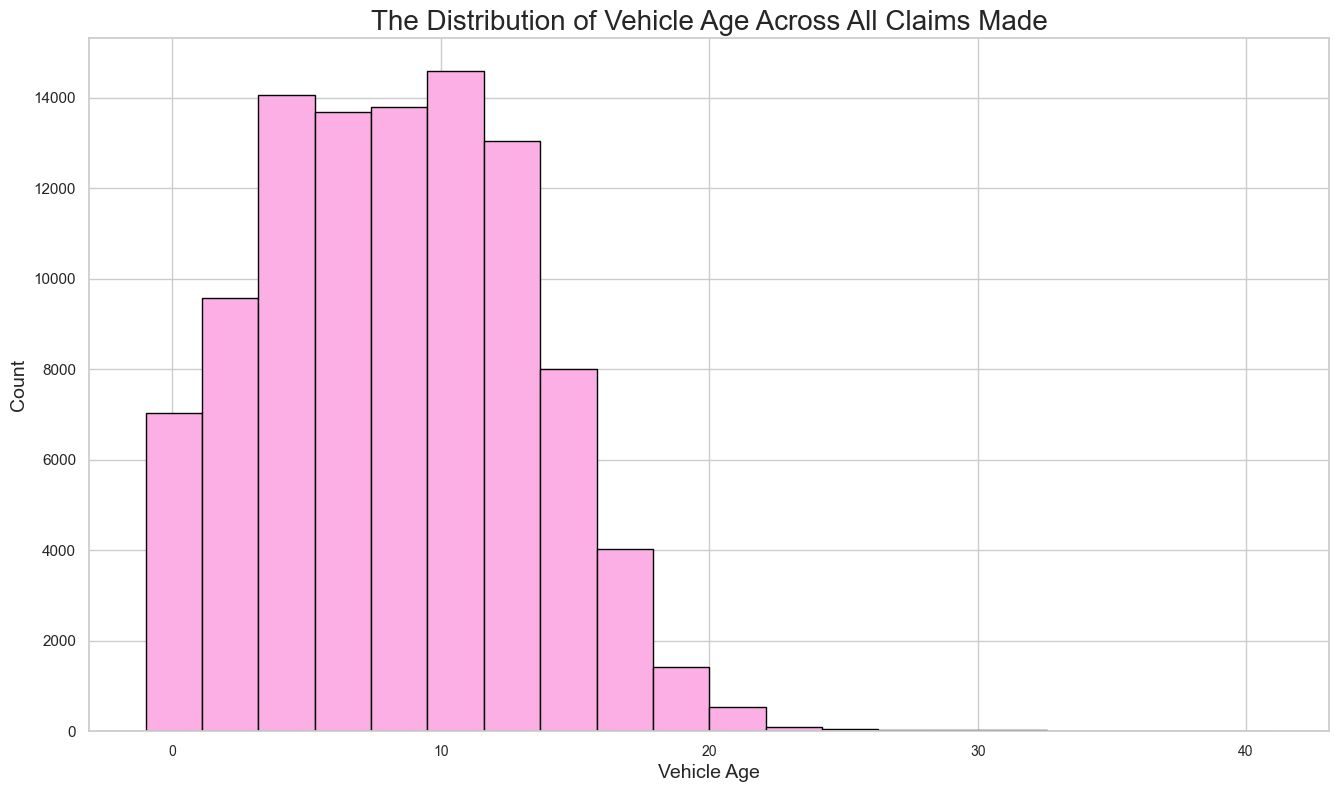

In [5]:
#Plotting the Distribution of Vehicle Age
fig = plt.figure(figsize = (16,9))

sns.set_theme(style = "whitegrid")

plt.hist(df["vehicle_age"],
        edgecolor = "black",
        bins = 20,
        color = sns.color_palette("colorblind")[6])

plt.xlabel("Vehicle Age", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.title("The Distribution of Vehicle Age Across All Claims Made", fontsize = 20)
plt.xticks(fontsize = 10)

plt.show()

sns.set_theme(style = "whitegrid")

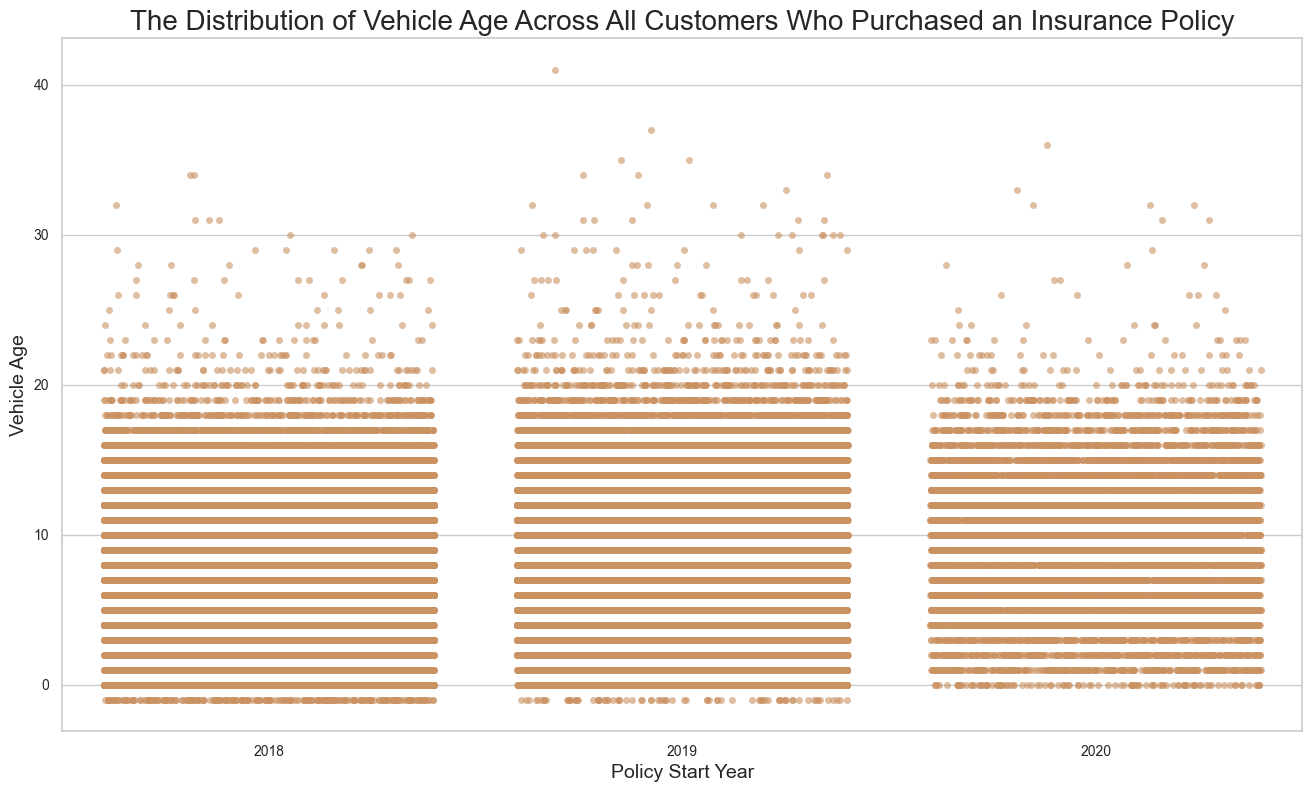

In [6]:
#Vehicle Age by Policy Start Year

# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "vehicle_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[5])

plt.xlabel("Policy Start Year", fontsize = 14),
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Age", fontsize = 14)
plt.yticks(fontsize = 10)
plt.title("The Distribution of Vehicle Age Across All Customers Who Purchased an Insurance Policy", fontsize = 20)

plt.show()

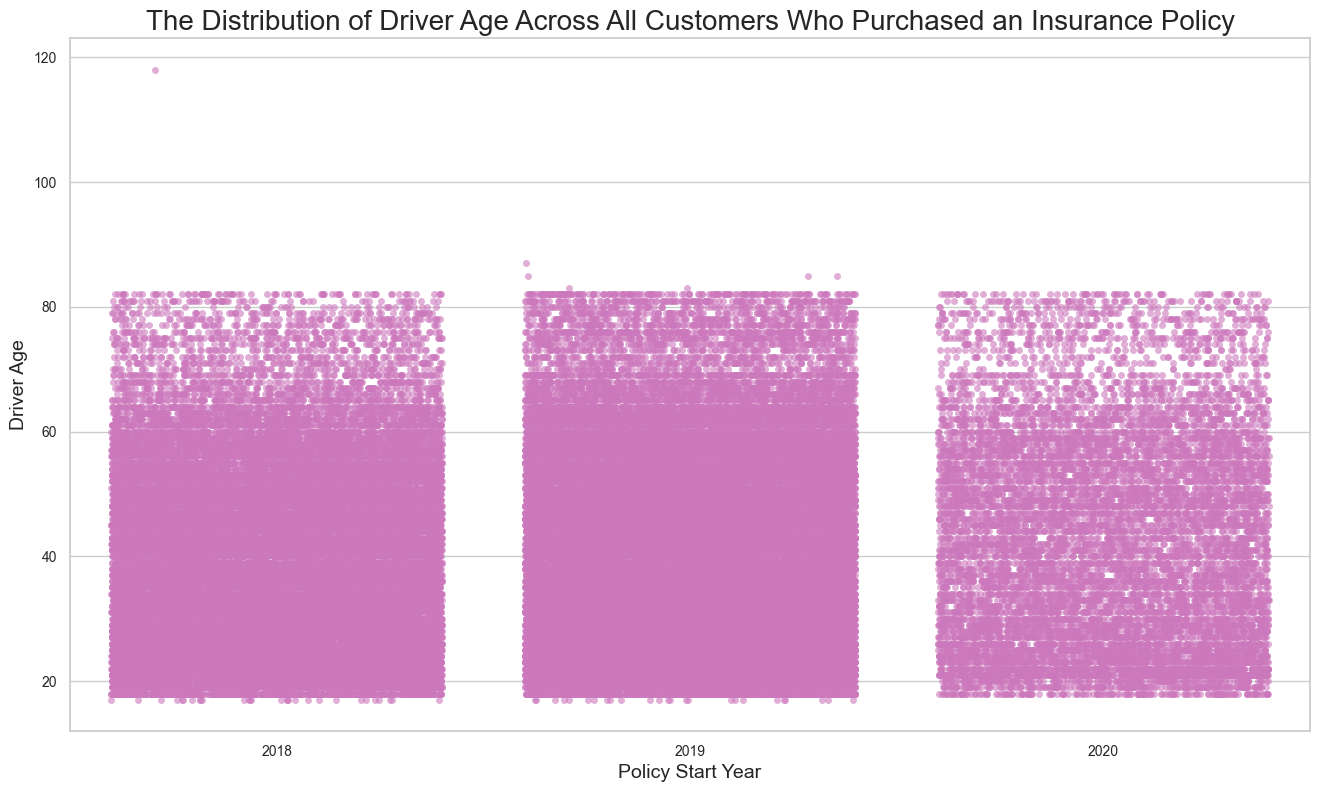

In [7]:
#Plotting Distribution of Driver Age
fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "d1_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[4])

plt.xlabel("Policy Start Year", fontsize = 14),
plt.xticks(fontsize = 10)
plt.ylabel("Driver Age", fontsize = 14)
plt.yticks(fontsize = 10)
plt.title("The Distribution of Driver Age Across All Customers Who Purchased an Insurance Policy", fontsize = 20)

plt.show()

In [8]:
#Identifying the number of negative 'Incurred' values
neg_incurred = (
    (df.loc[:, list(df.columns[df.columns.str.endswith("incurred")][1:])] < 0)
        .sum()
        .reset_index()
        .rename(columns = {"index":"Column", 0:"Total Negative Values"})
        .sort_values("Total Negative Values", ascending = False, ignore_index = True)
)

neg_incurred
#neg_incurred.to_csv(Path.cwd() / "Reports" / "negative_incurred.csv", index = False)

,Column,Total Negative Values
0,ad_incurred,1715
1,incurred,1073
2,capped_incurred,1073
3,pd_incurred,6
4,th_incurred,1
5,bi_incurred,0
6,ws_incurred,0


### Replacing Values

In [9]:
## Replacing Values

#Cleaning up the name of business providers
df["business_group"] = np.select(
    [
        # Google
        df["business_provider"].str.contains("Google", na=False),

        # Bing
        df["business_provider"].str.contains("Bing", na=False),

        # Price comparison websites
        df["business_provider"].str.startswith("CTM") |
        df["business_provider"].str.startswith("Confused") |
        df["business_provider"].str.startswith("GoCompare") |
        df["business_provider"].str.startswith("MSM") |
        df["business_provider"].str.startswith("Quotezone") |
        df["business_provider"].str.startswith("uSwitch") |
        df["business_provider"].str.startswith("PCWebsite"),

        # Cashback / rewards
        df["business_provider"].str.startswith("Quidco") |
        df["business_provider"].str.startswith("TopCashBack") |
        df["business_provider"].str.startswith("RewardGateway"),

        # Hastings website
        df["business_provider"].str.startswith("HDWebsite") |
        df["business_provider"].str.startswith("IPWebsite") |
        df["business_provider"].str.startswith("Insurer") |
        df["business_provider"].str.startswith("ContactUsPage") |
        df["business_provider"].str.startswith("Default"),

        # Email
        df["business_provider"].str.lower().str.contains("email", na=False),

        # Existing customers
        df["business_provider"].str.startswith("RenewalRebroke") |
        df["business_provider"].str.startswith("MTARebroke") |
        df["business_provider"].str.startswith("Policy_Booklets"),

        # Programmatic advertising
        df["business_provider"].str.startswith("Programmatic"),

        # Direct marketing
        df["business_provider"].str.startswith("Otherdirectmarketing"),

        # Cross-sell
        df["business_provider"].str.startswith("Home_Insurance"),

        # Unknown
        df["business_provider"].str.startswith("Unknown")
    ],
    [
        "Google",
        "Bing",
        "Price Comparison Website",
        "Cashback/Rewards",
        "Hastings Website",
        "Email",
        "Existing Customer",
        "Programmatic Advertising",
        "Direct Marketing",
        "Cross-sell",
        "Unknown"
    ],
    default="Other"
)


#Replacing age 118 with NaN
df["d1_age"] = df["d1_age"].where(df["d1_age"] != 118)

df["d1_residency_years"] = df["d1_residency_years"].where(df["d1_residency_years"] != 118)

#Replacing NA with 0
df["incurred"] = df["incurred"].fillna(0)
df["capped_incurred"] = df["capped_incurred"].fillna(0)
df["bi_incurred"] = df["bi_incurred"].fillna(0)
df["ad_incurred"] = df["ad_incurred"].fillna(0)
df["pd_incurred"] = df["pd_incurred"].fillna(0)
df["th_incurred"] = df["th_incurred"].fillna(0)
df["ws_incurred"] = df["ws_incurred"].fillna(0)

df["bi_count"] = df["bi_count"].fillna(0)
df["ad_count"] = df["ad_count"].fillna(0)
df["pd_count"] = df["pd_count"].fillna(0)
df["th_count"] = df["th_count"].fillna(0)
df["ws_count"] = df["ws_count"].fillna(0)

df["is_capped_incurred"] = df["is_capped_incurred"].fillna(0)


#Calculating absolute values of all negative "incurred" values and Recalculating the incurred column
df["ad_incurred"] = df["ad_incurred"].abs()
df["th_incurred"] = df["th_incurred"].abs()
df["pd_incurred"] = df["pd_incurred"].abs()

df["incurred"] = df["ad_incurred"] + df["bi_incurred"] + df["pd_incurred"] + df["th_incurred"] + df["ws_incurred"]

df["capped_incurred"] = np.select(
    [
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] < 50000),
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] >= 50000),
        df["is_capped_incurred"] == 0
    ],
    [
        df["incurred"],
        50000,
        df["incurred"]
    ],
    df["capped_incurred"]
)    


#Filling in NAs for net_earned_premium
df["net_earned_premium"] = df["net_earned_premium"].where(~df["net_earned_premium"].isna(),
                                                         df["net_written_premium"] * df["exposure"])


#Replacing negatives values with NaN
df["vehicle_age"] = df["vehicle_age"].where(df["vehicle_age"] >= 0)


## Changing Casing
df["vehicle_make"] = df["vehicle_make"].str.title()

df["transmission"] = df["transmission"].str.title()

### Adding New Columns

In [10]:
#Adding new column for 'Driving Years'
#Notice there are some minus values, perhaps they are just prepared

#df["days_driving"] = df["start_date"] - df["licence_test_date"]
df["years_driving"] = (df["start_date"] - df["licence_test_date"]) / pd.Timedelta(days=365.25)

df["experience_group"] = pd.cut(
    df["years_driving"],
    bins=[
        -np.inf, 0,
        10, 20, 30,
        40, 50, 60,
        np.inf
    ],
    labels=[
        "<0 years",
        "0-10 years",
        "10-20 years",
        "20-30 years",
        "30-40 years",
        "40-50 years",
        "50-60 years",
        "60+ years"
    ]
)


df["vehicle_value_band"] = pd.cut(
    df["vehicle_value"],
    bins=[
        0,
        2000, 4000, 6000,
        8000, 10000, np.inf
    ],
    labels=[
        "£0-2000",
        "£2000-4000",
        "£4000-6000",
        "£6000-8000",
        "£8000-10000",
        "£10000+"
    ]
)

### Checking Duplicates

In [11]:
# Checking for duplicate rows
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print(f"{df.duplicated().sum()} rows are duplicated")

print(f"{df["id"].duplicated().sum()} ID values are duplicated")


Dataset has 100000 rows and 45 columns
0 rows are duplicated
0 ID values are duplicated


### Checking Values

In [12]:
# Checking column values
#df.groupby("ws_incurred").groups.keys()

#### Looking at the values in each column, below are issues that should be addressed:

*Data Types*
- is_capped_incurred is float
- bi_count is float
- ad_count is float
- pd_count is float
- th_count is float
- ws_count is float
- vehicle_age is float

*Numeric Values*
- ad_incurred has negative values
- th_incurred has negative values
- incurred has negative values
- capped_incurred has negative values
- d1_age contains "118" values.
- d1_residency_years contains "118" values
- vehicle_value has a range of values, including single digits (not decided)
- vehicle_age contains negative values

*Character Values*
- business_provider has multiple formats for values (may be more work)
- vehicle_make is all capitalised
- transmission is all capitalised

### Profiling Missing Data 2

In [13]:
# Profiling missing values
missing_values_after = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_after.to_csv(Path.cwd() / "Reports" / "missing_values_after.csv", index=False)

# High-Level Analysis

### Number of Policies Written

In [14]:
# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

#policies = (
 #   df.groupby("start_year").id.count()
  #      .reset_index()
   #     .rename(columns = {"start_year":"Start Year", "id":"Number of Policies"})
#)

policies = (
    df.groupby("start_year")
    .agg(
        policies = ("id", "count"),
        first_date = ("start_date", "min"),
        last_date = ("start_date", "max")
    )
    .reset_index()
    .rename(columns = {
        "start_year":"Start Year",
        "policies":"Number of Policies",
        "first_date":"First Policy Date",
        "last_date":"Last Policy Date"
    }
           )
)

policies["First Policy Date"] = pd.to_datetime(policies["First Policy Date"], format = "%d-%m-%Y")

policies
#policies.to_csv(Path.cwd() / "Reports" / "policies.csv", index = False)

,Start Year,Number of Policies,First Policy Date,Last Policy Date
0,2018,38539,2018-04-01,2018-12-31
1,2019,49808,2019-01-01,2019-12-31
2,2020,11653,2020-01-01,2020-03-31


Policies written in 2020 could be low due to Covid and fewer people driving/more people working from home

### Frequency of Claims Counts

In [15]:
# Frequency of claims count
claim_frequency = pd.DataFrame(df.groupby("claim_count")
                               .id
                               .count()
                               .reset_index()
                               .rename(columns={"claim_count":"Claims Count",
                                                "id": "Frequency"}))

claim_frequency["Percentage"] = (claim_frequency["Frequency"] / claim_frequency["Frequency"].sum()) * 100
claim_frequency
# Exporting
#claim_frequency.to_csv("Reports/claim_frequency.csv", index=False)

,Claims Count,Frequency,Percentage
0,0,92581,92.581
1,1,6937,6.937
2,2,452,0.452
3,3,27,0.027
4,4,3,0.003


### Profit

In [16]:
# Calculating the total cost per person
df["final_incurred"] = np.where(df["is_capped_incurred"].fillna(0) == 1,
                                df["capped_incurred"],
                                df["incurred"])

# Calculating Profitability
df["profit"] = df["net_earned_premium"].fillna(0) - df["final_incurred"].fillna(0)

print(f"The gross earned premiums is {round(df["net_earned_premium"].sum(), 2)}")
print(f"The total incurred charges is {round(df["final_incurred"].sum(), 2)}")
print(f"Total profit made in this period is {round(df['profit'].sum(), 2)}")

profit = (
    df.groupby("start_year").agg(
        total_profit = ("profit", "sum"),
        mean_profit = ("profit", "mean")
    )
    .reset_index()
    .rename(columns = {"start_year":"Start Year",
                       "total_profit":"Total Profit (millions)",
                       "mean_profit":"Mean Profit"})
)
profit["Total Profit (millions)"] = round(profit["Total Profit (millions)"] / 1000000, 2)
profit["Mean Profit"] = round(profit["Mean Profit"], 2)

profit
#profit.to_csv(Path.cwd() / "Reports" / "profit.csv", index = False)

The gross earned premiums is 27237225.85
The total incurred charges is 19607094.15
Total profit made in this period is 7630131.7


,Start Year,Total Profit (millions),Mean Profit
0,2018,3.43,89.05
1,2019,3.94,79.19
2,2020,0.25,21.77


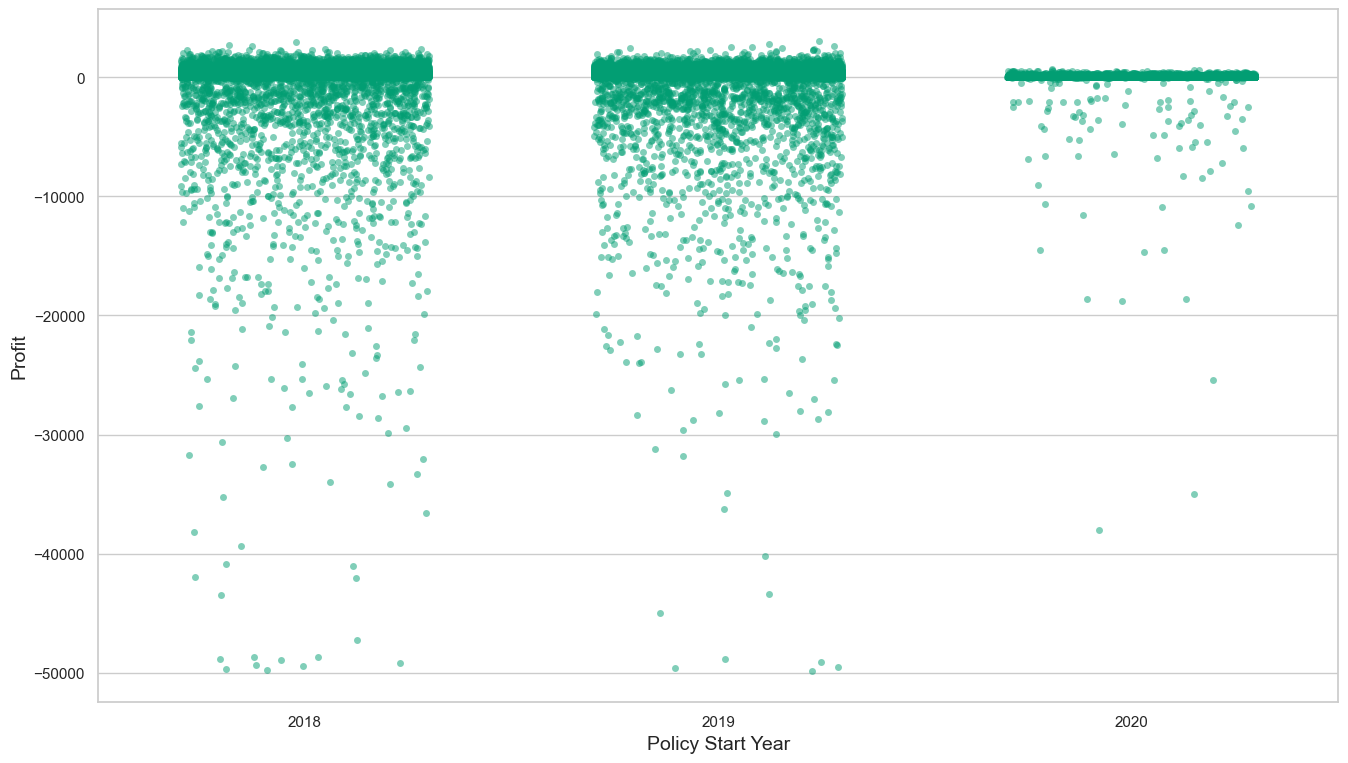

In [17]:
fig = plt.figure(figsize = (16,9))

sns.stripplot(data = df,
            x = "start_year",
            y = "profit",
            jitter = 0.3,
            alpha = 0.5,
            color = sns.color_palette("colorblind")[2])
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("Profit", fontsize = 14)

plt.show()

### FREQUENCY AND SEVERITY

In [18]:
# Calculating Claims Frequency
claims_frequency = df["claim_count"].sum() / df["exposure"].sum()

print(f"The total number of claims is {df["claim_count"].sum()}")
print(f"The total number of vehicles vehicle-years at risk is {round(df['exposure'].sum(), 2)}")
print(f"The claims frequency is {round(claims_frequency, 2)} claims per year")

frequency = (
    df.groupby("start_year")[["exposure", "claim_count"]]
        .sum()
)
frequency["frequency"] = round(frequency["claim_count"] / frequency["exposure"], 6)

#frequency.to_csv(Path.cwd () / "Reports" / "frequency.csv", index = False)

The total number of claims is 7934
The total number of vehicles vehicle-years at risk is 71959.47
The claims frequency is 0.11 claims per year


In [19]:
severity = (
    df.groupby("start_year")
      .agg(
          total_incurred=("final_incurred", "sum"),
          total_claims=("claim_count", "sum")
      )
)

severity["severity"] = (
    severity["total_incurred"]
    / severity["total_claims"]
)
severity

,total_incurred,total_claims,severity
start_year,,,
2018,9942032.88,4065,2445.764546
2019,9127966.39,3700,2467.017943
2020,537094.88,169,3178.076213


In [20]:
#Overall frequency, severity, pure premium and written premium
total_policies = df["id"].count()

total_claims = df["claim_count"].sum()

claims_frequency = df["claim_count"].sum() / df["exposure"].sum()

claims_severity = df["final_incurred"].sum() / df["claim_count"].sum()

pure_premium = claims_frequency * claims_severity

ave_written_premium = df["net_written_premium"].sum() / len(df["net_written_premium"])

added_on = ave_written_premium - pure_premium

df_summary = pd.DataFrame(
    {"Policies":total_policies,
     "Claims":total_claims,
     "Frequency":round(claims_frequency, 2),
    "Severity":round(claims_severity, 2),
    "Pure Premium":round(pure_premium, 2),
    "Written Premium":round(ave_written_premium, 2),
    "Added_on":round(added_on, 2)},
    index = [0]
)

df_summary

#df_summary.to_csv(Path.cwd() / "Reports" / "high_level_summary.csv", index = False)

,Policies,Claims,Frequency,Severity,Pure Premium,Written Premium,Added_on
0,100000,7934,0.11,2471.27,272.47,364.27,91.8


In [21]:
freq_sev = (
    pd.merge(frequency, severity, left_on=frequency.index,right_on=severity.index)
        .drop(columns = "total_claims")
        .rename(columns = {"key_0":"start_year", "claim_count":"claims"})
        .iloc[:, [0, 2, 1, 4, 3, 5]]
)

freq_sev["pure_premium"] = freq_sev["frequency"] * freq_sev["severity"]

freq_sev

,start_year,claims,exposure,total_incurred,frequency,severity,pure_premium
0,2018,4065,34379.416438,9942032.88,0.118239,2445.764546,289.184754
1,2019,3700,35402.257134,9127966.39,0.104513,2467.017943,257.835446
2,2020,169,2177.800742,537094.88,0.077601,3178.076213,246.621892


In [22]:
freq_sev2 = freq_sev.merge(
    right = df.groupby("start_year").net_written_premium.mean().reset_index(),
    on = "start_year")

freq_sev2["added_on"] = freq_sev2["net_written_premium"] - freq_sev2["pure_premium"]

freq_sev2.columns = [
    "Start Year", "Claims", "Years at Risk", "Total Incurred", "Frequency", "Severity", "Pure Premium",
    "Net Written Premium", "Added On"
]

for col in freq_sev2.select_dtypes(include="number").columns:
    freq_sev2[col] = round(freq_sev2[col], 2)


freq_sev2
#freq_sev2.to_csv(Path.cwd() / "Reports" / "frequency_severity.csv", index = False)

,Start Year,Claims,Years at Risk,Total Incurred,Frequency,Severity,Pure Premium,Net Written Premium,Added On
0,2018,4065,34379.42,9942032.88,0.12,2445.76,289.18,380.11,90.92
1,2019,3700,35402.26,9127966.39,0.10,2467.02,257.84,355.31,97.47
2,2020,169,2177.80,537094.88,0.08,3178.08,246.62,350.22,103.60


In [23]:
#Frequency & Severity of each claim type
freq_sev_type = pd.DataFrame({
    "frequency": [
        df["bi_count"].sum() / df["exposure"].sum(),
        df["ad_count"].sum() / df["exposure"].sum(),
        df["pd_count"].sum() / df["exposure"].sum(),
        df["th_count"].sum() / df["exposure"].sum(),
        df["ws_count"].sum() / df["exposure"].sum()
    ],
    "severity": [
        df["bi_incurred"].sum() / df["bi_count"].sum(),
        df["ad_incurred"].sum() / df["ad_count"].sum(),
        df["pd_incurred"].sum() / df["pd_count"].sum(),
        df["th_incurred"].sum() / df["th_count"].sum(),
        df["ws_incurred"].sum() / df["ws_count"].sum()
    ]
}, index=["Bodily Injuries", "Accidental", "Third Party Property", "Fire/Theft", "Windscreen"])

freq_sev_type["pure_premium"] = freq_sev_type["frequency"] * freq_sev_type["severity"]

freq_sev_type = (
    freq_sev_type.sort_values("severity", ascending=False)
    .rename(columns = {
        "frequency":"Frequency",
        "severity":"Severity",
        "pure_premium":"Pure Premium"
    })
)

freq_sev_type["Frequency"] = round(freq_sev_type["Frequency"], 3)
freq_sev_type["Severity"] = round(freq_sev_type["Severity"], 2)
freq_sev_type["Pure Premium"] = round(freq_sev_type["Pure Premium"], 2)

freq_sev_type = (
    freq_sev_type.reset_index()
    .rename(columns = {"index":"Claim Type"})
)

freq_sev_type
#freq_sev_type.to_csv(Path.cwd() / "Reports" / "frequency_severity_by_type.csv", index = False)

,Claim Type,Frequency,Severity,Pure Premium
0,Bodily Injuries,0.012,8563.96,101.99
1,Fire/Theft,0.002,3774.47,8.60
2,Third Party Property,0.043,2618.57,111.50
3,Accidental,0.069,1005.31,69.06
4,Windscreen,0.026,105.13,2.78


## Profiling Customer Who Made Claims

### Number of Claims by Policy Year

In [24]:
# Calculating number of claims by start_year and the number of people making claims
yearly_claims = (
    pd.merge(left = df.groupby("start_year").claim_count.sum().reset_index(),
        right = df[df["claim_count"] > 0].groupby("start_year").id.count().reset_index(),
        on = "start_year")
    .rename(columns={"start_year":"Start Year",
                     "claim_count":"Total Claims",
                     "id":"Number of Customers",})
)

yearly_claims

,Start Year,Total Claims,Number of Customers
0,2018,4065,3767
1,2019,3700,3486
2,2020,169,166


### Type of Claims Made

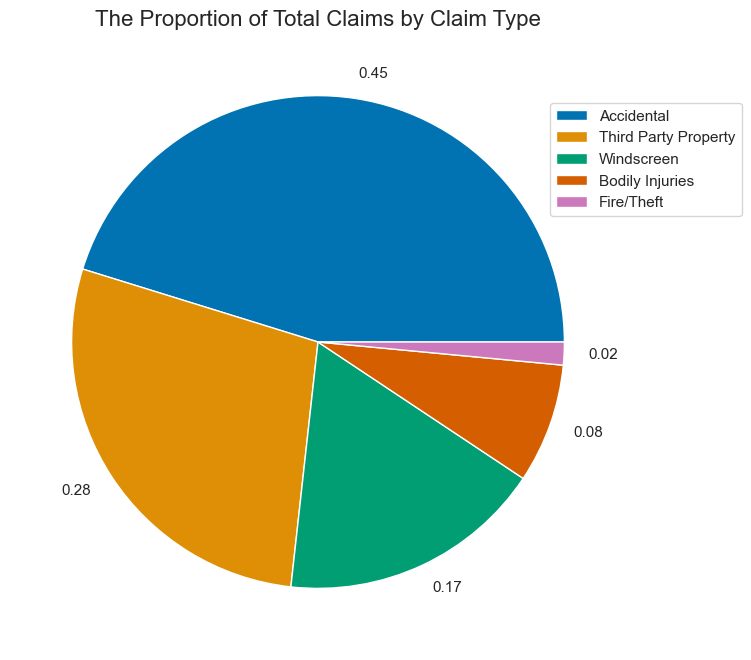

In [25]:
#Subsetting dataframe for policies with a claim
df_claimed = df[df["claim_count"] > 0]


# Calculating the number of each claim type made
claims_by_type = (
    df_claimed.loc[:, ["bi_count", "ad_count", "pd_count", "th_count", "ws_count"]].sum()
    .reset_index()
)
claims_by_type.columns = ["Type", "Frequency"]

#Replacing values
claims_by_type["Type"] = claims_by_type["Type"].str.replace(
    {
        "ad_count":"Accidental",
        "pd_count":"Third Party Property",
        "ws_count":"Windscreen",
        "bi_count":"Bodily Injuries",
        "th_count": "Fire/Theft"
    }
)
#Sorting by descending frequency
claims_by_type = claims_by_type.sort_values("Frequency", ascending=False)

# Calculating Proportion
claims_by_type["Proportion"] = claims_by_type["Frequency"] / claims_by_type["Frequency"].sum()


#Plotting a pie chart
fig = plt.figure(figsize = (8, 8))

plt.pie(data = claims_by_type,
        x = "Proportion",
        labels = round(claims_by_type["Proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"], loc='upper right', bbox_to_anchor=(1.2, 0.9))
plt.title("The Proportion of Total Claims by Claim Type", fontsize = 16)

plt.show()

## Investigating Severity by Factors

### Severity by Vehicle-use

In [26]:
#Calculating Severity for each Vehicle-Use
severity_by_use = (
    df_claimed.groupby("vehicle_use")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)

severity_by_use["severity"] = round(severity_by_use["total_incurred"] / severity_by_use["claims"], 2)

severity_by_use["vehicle_use"] = severity_by_use["vehicle_use"].replace({
                                                  "B":"Business",
                                                  "C":"Commuting and Social",
                                                  "S":"Social/Domestic/Pleasure"
                                              }
)
severity_by_use

#severity_by_use.to_csv(Path.cwd() / "Reports" / "severity_by_vehicle_use.csv", index = False)

,vehicle_use,total_incurred,claims,severity
0,Business,32077.70,16,2004.86
1,Commuting and Social,13006505.81,5354,2429.31
2,Social/Domestic/Pleasure,6568510.64,2564,2561.82


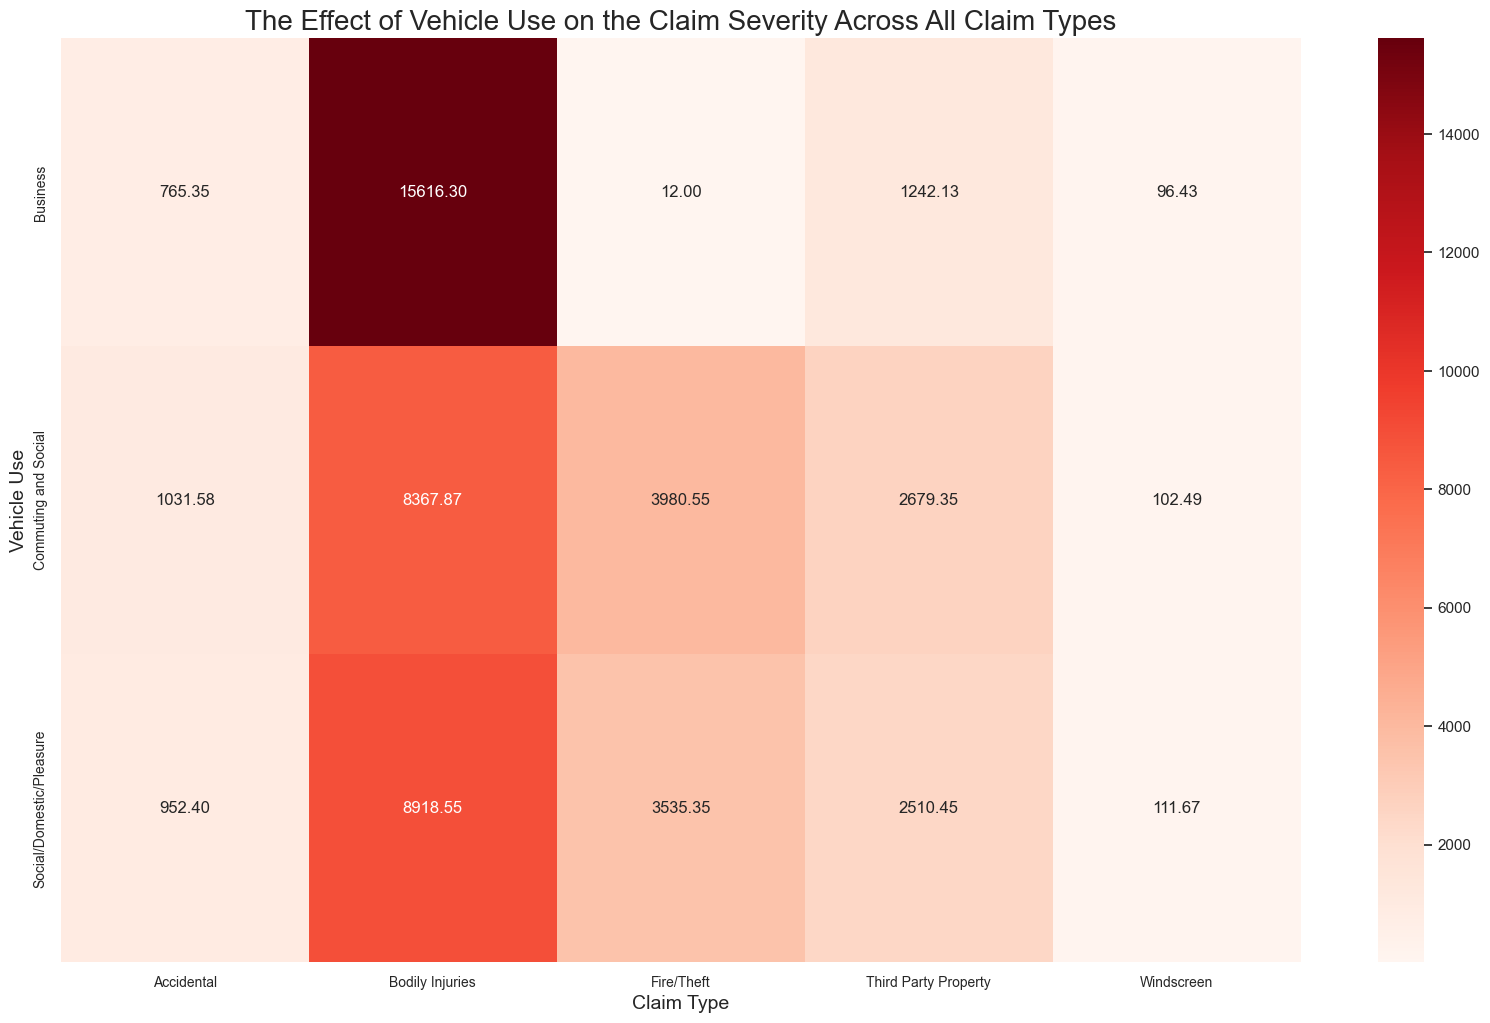

In [27]:
#Calculating Severity for each Vehicle-Use, for each claim type
severity_by_use_type, s_pivot = severity_calc(df = df_claimed,
                                              by_group = "vehicle_use",
                                              key = {
                                                  "B":"Business",
                                                  "C":"Commuting and Social",
                                                  "S":"Social/Domestic/Pleasure"
                                              }
)

s_pivot = s_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot,
            annot=True,
            fmt=".2f",
            cmap="Reds")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Use", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Use on the Claim Severity Across All Claim Types", fontsize = 20)

plt.show()

### Severity by Overnight Location

In [28]:
#Calculating Severity for each Overnight Location
severity_by_loc = (
    df_claimed.groupby("overnight_location")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
severity_by_loc["severity"] = round(severity_by_loc["total_incurred"] / severity_by_loc["claims"], 2)

severity_by_loc["overnight_location"] = severity_by_loc["overnight_location"].replace(
    {
        "D":"Driveway",
        "G":"Garage",
        "R":"Road/Street"
    }
)

severity_by_loc

#severity_by_loc.to_csv(Path.cwd() / "Reports" / "severity_by_location.csv", index= False)

,overnight_location,total_incurred,claims,severity
0,Driveway,12111607.90,5097,2376.22
1,Garage,1267561.80,418,3032.44
2,Road/Street,6227924.45,2419,2574.59


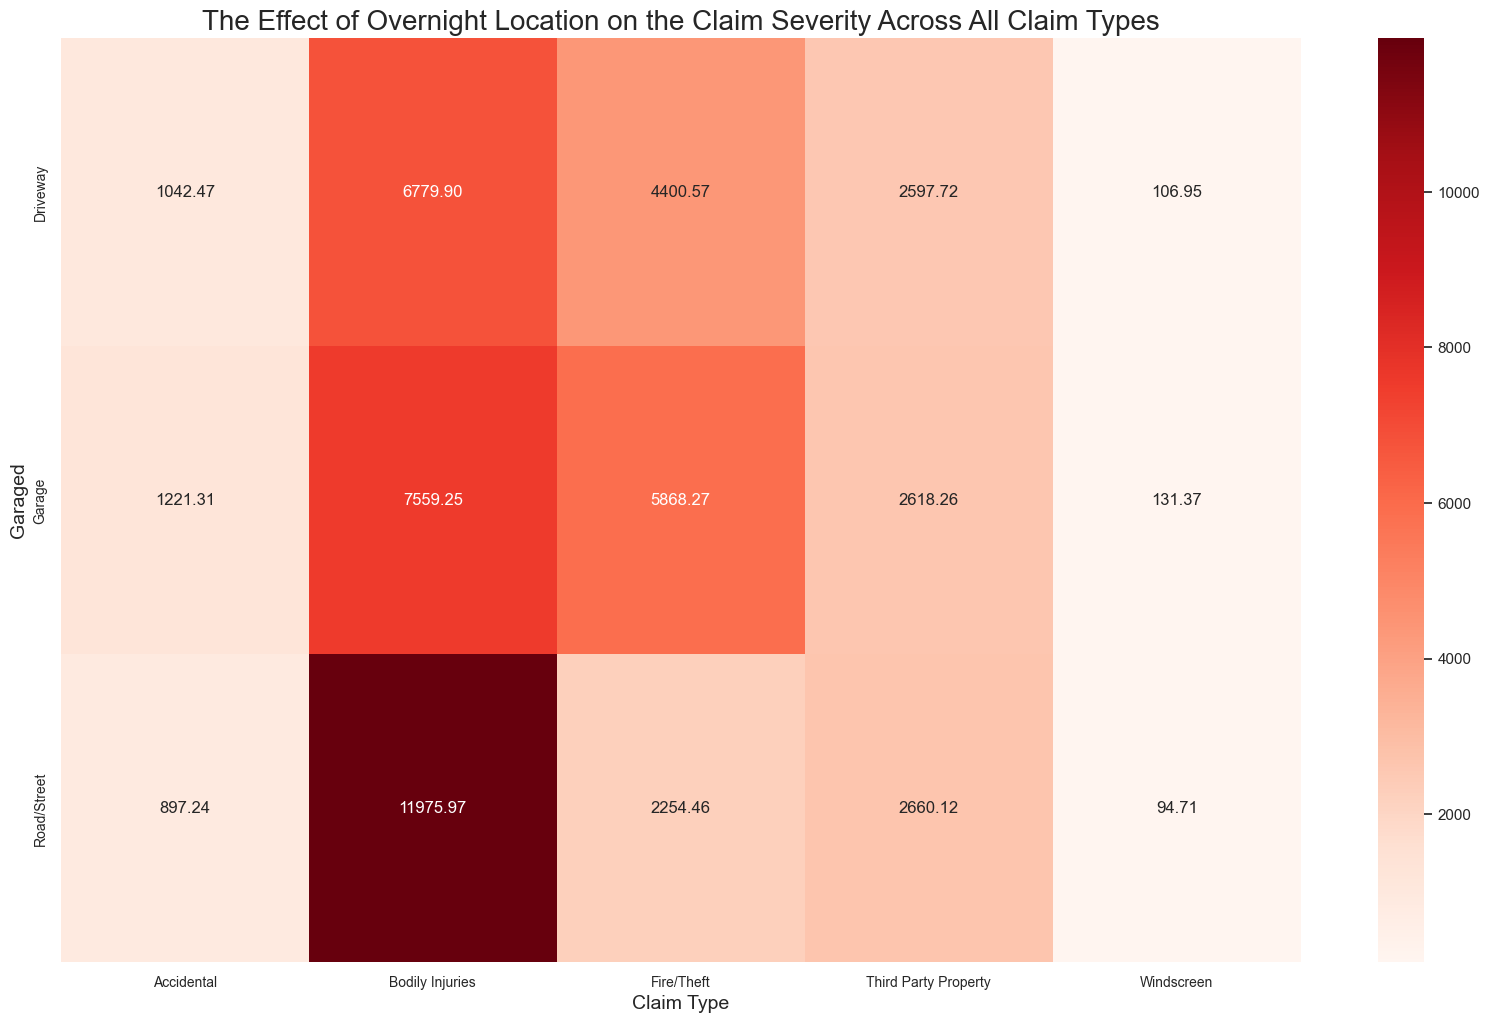

In [29]:
#Calculating Severity for each Overnight Location, for each claim type
severity_by_loc_type, s_pivot2 = severity_calc(df = df_claimed,
                                              by_group = "overnight_location",
                                              key = {
                                                  "D":"Driveway",
                                                  "G":"Garage",
                                                  "R":"Road/Street"
                                              }
)

s_pivot2 = s_pivot2.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot2,
            annot=True,
            fmt=".2f",
            cmap="Reds")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Garaged", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Overnight Location on the Claim Severity Across All Claim Types", fontsize = 20)

plt.show()

### Severity by Experience

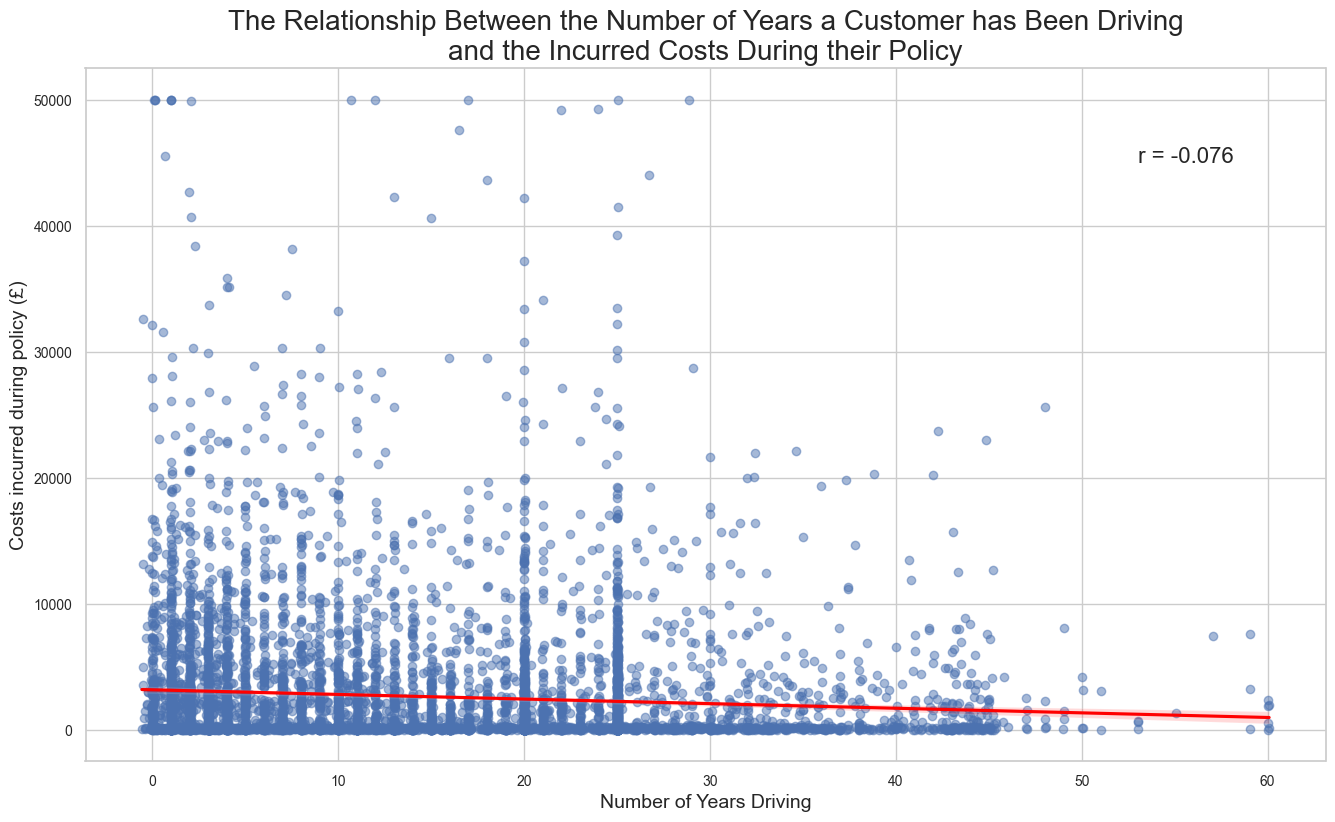

In [30]:
#Plotting costs incurred per policy by customer experience

#Calculating the correlation coefficient
r = df_claimed["years_driving"].corr(df_claimed["final_incurred"])

plt.figure(figsize=(16, 9))

sns.regplot(
    data=df_claimed,
    x="years_driving",
    y="final_incurred",
    scatter_kws={"alpha": 0.5},
    line_kws={"color":"red"}
)
plt.text(x = 53,
        y = 45000,
        s = f"r = {round(r, 3)}",
        fontsize = 16)

plt.xlabel("Number of Years Driving", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Costs incurred during policy (£)", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title('''The Relationship Between the Number of Years a Customer has Been Driving
and the Incurred Costs During their Policy''',
         fontsize = 20)

plt.show()

In [31]:
#Calculating Severity for each Experience band
severity_by_exp = (
    df_claimed.groupby("experience_group")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
severity_by_exp["severity"] = round(severity_by_exp["total_incurred"] / severity_by_exp["claims"], 2)

severity_by_exp

#severity_by_exp.to_csv(Path.cwd() / "Reports" / "severity_by_experience.csv", index = False)

,experience_group,total_incurred,claims,severity
0,<0 years,162079.90,47,3448.51
1,0-10 years,9617101.77,3320,2896.72
2,10-20 years,4037696.29,1833,2202.78
3,20-30 years,4466523.09,2097,2129.96
4,30-40 years,825443.13,399,2068.78
5,40-50 years,459698.73,218,2108.71
6,50-60 years,33614.38,15,2240.96
7,60+ years,4936.86,5,987.37


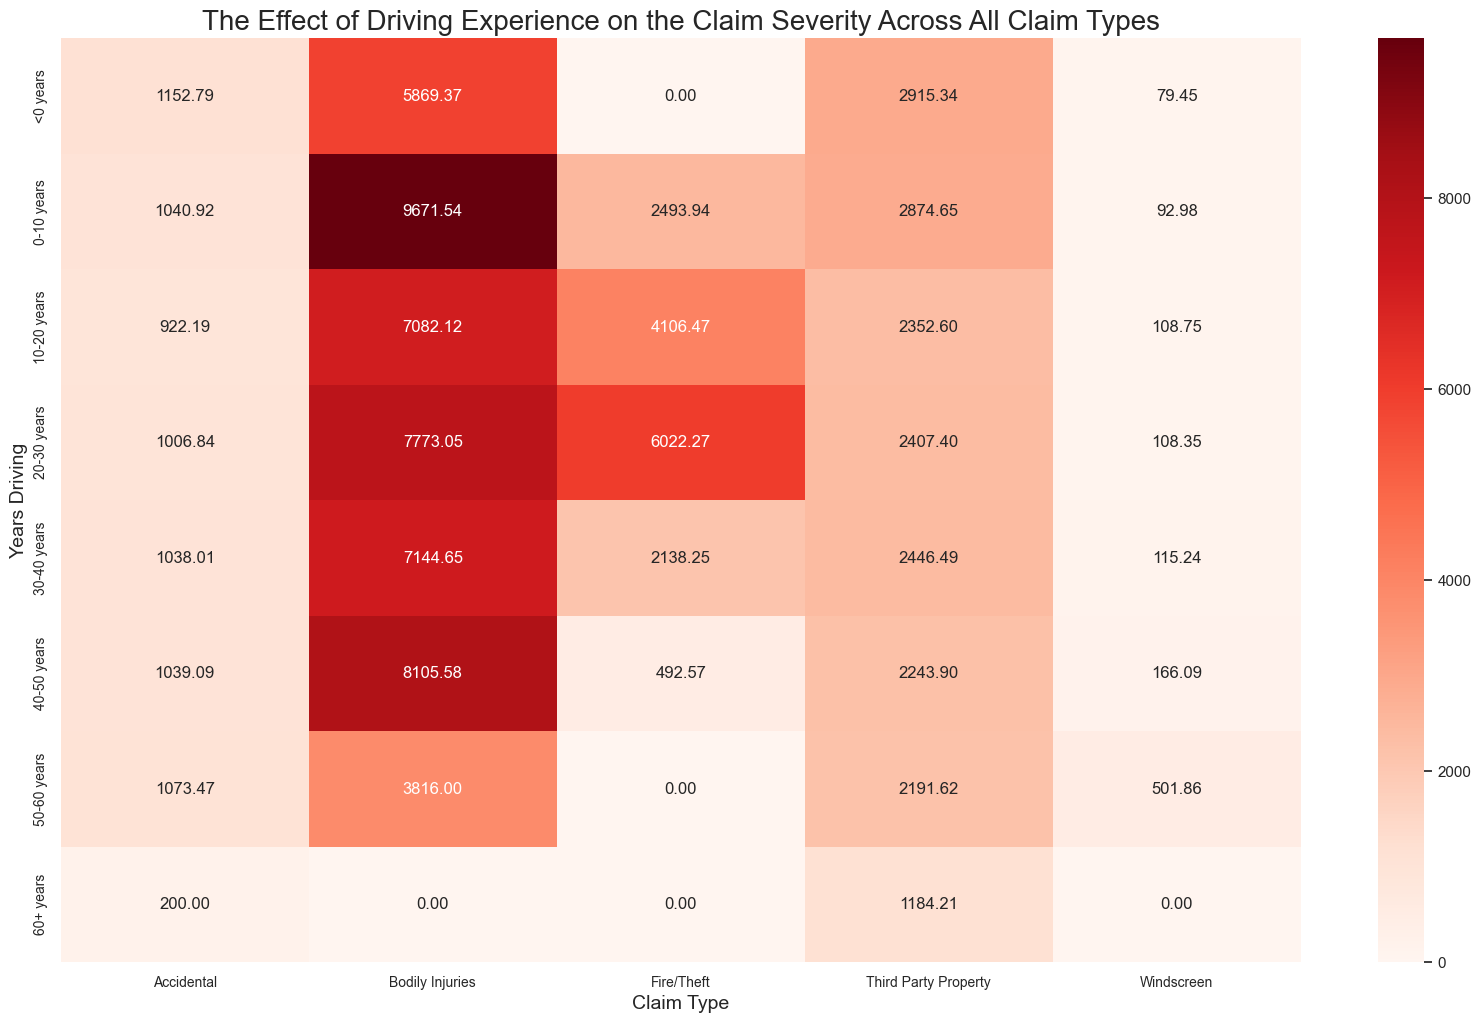

In [32]:
#Calculating Severity for each Experience band, for each claim type
severity_by_exp_type, s_pivot3 = severity_calc(df = df_claimed,
                                              by_group = "experience_group")

s_pivot3 = s_pivot3.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot3,
            annot=True,
            fmt=".2f",
            cmap="Reds")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Years Driving", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Driving Experience on the Claim Severity Across All Claim Types", fontsize = 20)

plt.show()

### Severity by Vehicle Value

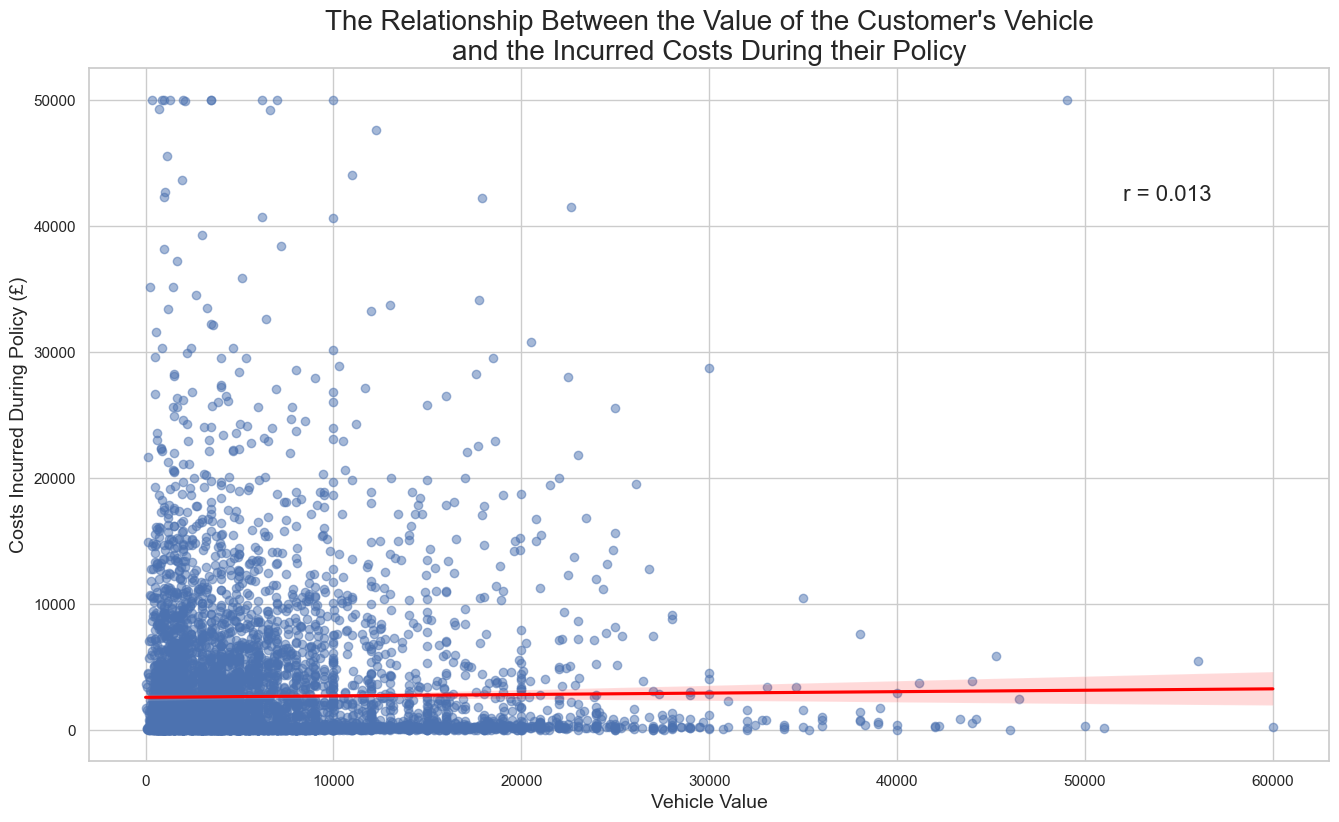

In [33]:
#Plotting the cost incurred for each policy against customer's vehicle value

#Calculating the correlation coefficient
r2 = df_claimed["vehicle_value"].corr(df_claimed["final_incurred"])

plt.figure(figsize=(16, 9))

sns.regplot(
    data=df_claimed,
    x="vehicle_value",
    y="final_incurred",
    scatter_kws={"alpha": 0.5},
    line_kws={"color":"red"}
)
plt.text(x = 52000,
       y = 42000,
         s = f"r = {round(r2, 3)}",
         fontsize = 16)

plt.xlabel("Vehicle Value", fontsize = 14)
plt.ylabel("Costs Incurred During Policy (£)", fontsize = 14)
plt.title('''The Relationship Between the Value of the Customer's Vehicle
and the Incurred Costs During their Policy''',
         fontsize = 20)

plt.show()

In [34]:
#Calculating Severity for each Vehicle Value band
severity_by_value = (
    df_claimed.groupby("vehicle_value_band")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
severity_by_value["severity"] = round(severity_by_value["total_incurred"] / severity_by_value["claims"], 2)

severity_by_value

#severity_by_value.to_csv(Path.cwd() / "Reports" / "severity_by_vehicle_value.csv", index = False)

,vehicle_value_band,total_incurred,claims,severity
0,£0-2000,5771204.81,2221,2598.47
1,£2000-4000,4022625.21,1699,2367.64
2,£4000-6000,2849603.71,1279,2227.99
3,£6000-8000,1979005.26,843,2347.57
4,£8000-10000,1487480.60,557,2670.52
5,£10000+,3497174.56,1335,2619.61


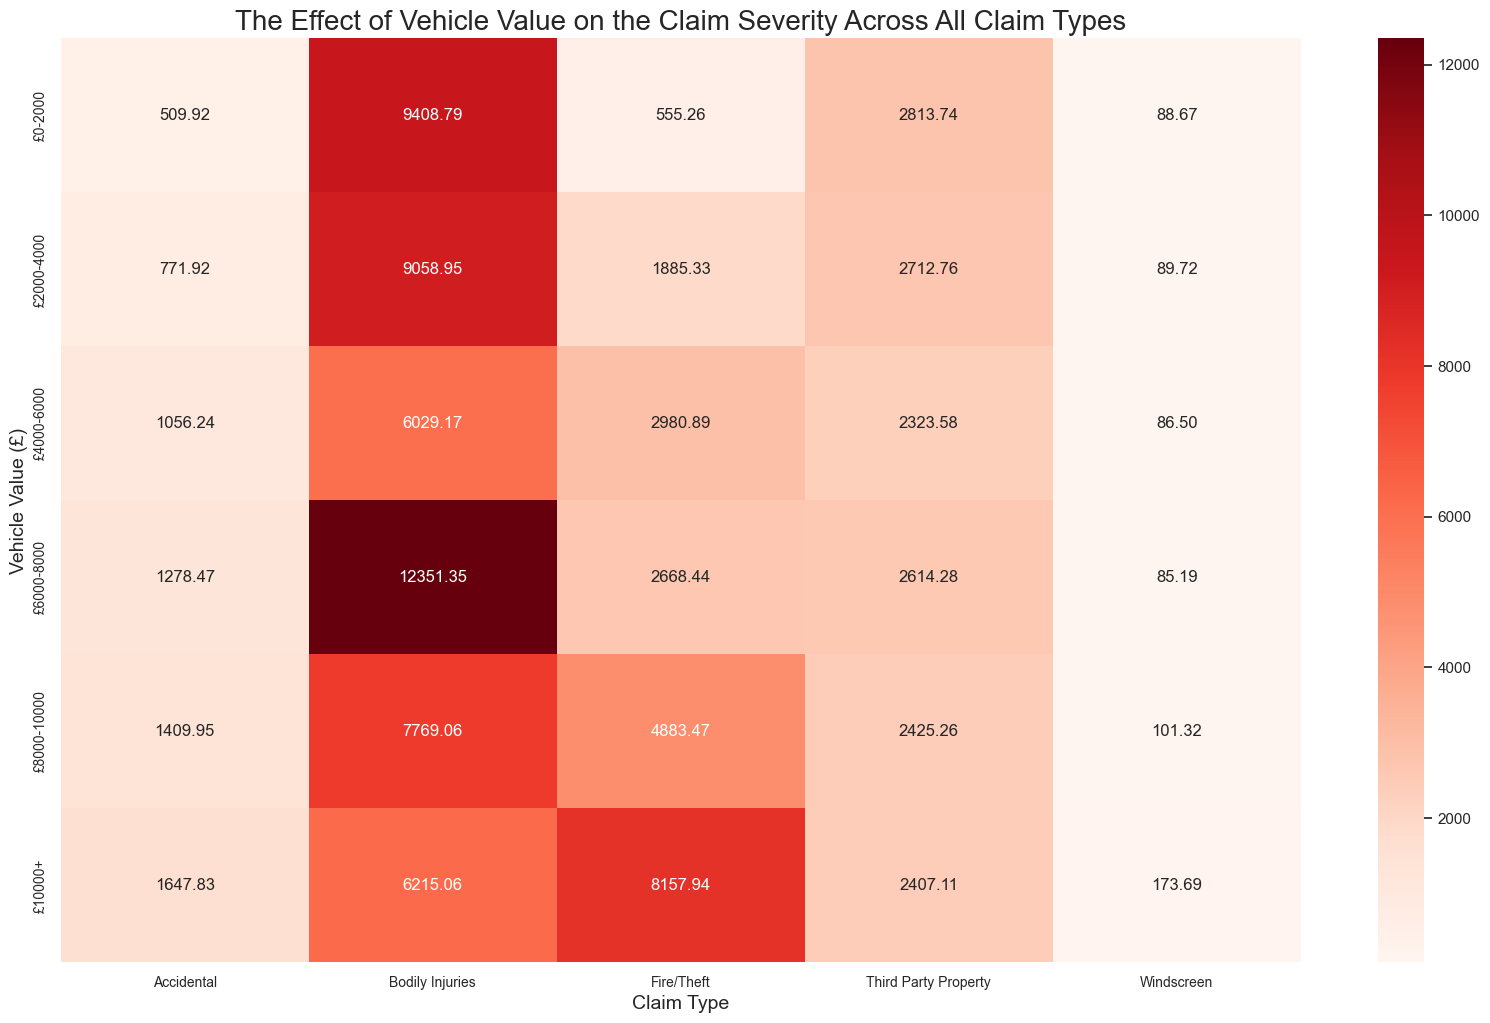

In [35]:
#Calculating Severity for each Vehicle Value band, for each claim type
severity_by_value_type, s_pivot4 = severity_calc(df = df_claimed,
                                              by_group = "vehicle_value_band")

s_pivot4 = s_pivot4.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot4,
            annot=True,
            fmt=".2f",
            cmap="Reds")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Value (£)", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Value on the Claim Severity Across All Claim Types", fontsize = 20)

plt.show()

### Severity by Region

In [36]:
#Calculating Severity for each Region
severity_by_region = (
    df_claimed.groupby("region")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
severity_by_region["severity"] = round(severity_by_region["total_incurred"] / severity_by_region["claims"], 2)

severity_by_region = severity_by_region.sort_values("severity", ascending = False)

severity_by_region

#severity_by_region.to_csv(Path.cwd() / "Reports" / "severity_by_region.csv", index = False)

,region,total_incurred,claims,severity
4,North,1507419.15,508,2967.36
3,N Ireland,332980.88,115,2895.49
5,North West,2984348.22,1033,2889.01
2,London,739056.88,263,2810.10
12,Yorkshire,2377419.27,860,2764.44
7,Scotland,981789.35,360,2727.19
10,Wales,1232904.24,458,2691.93
6,Outer London,1120075.96,445,2517.02
11,West Midlands,1574475.93,629,2503.14
8,South East,3124859.59,1378,2267.68


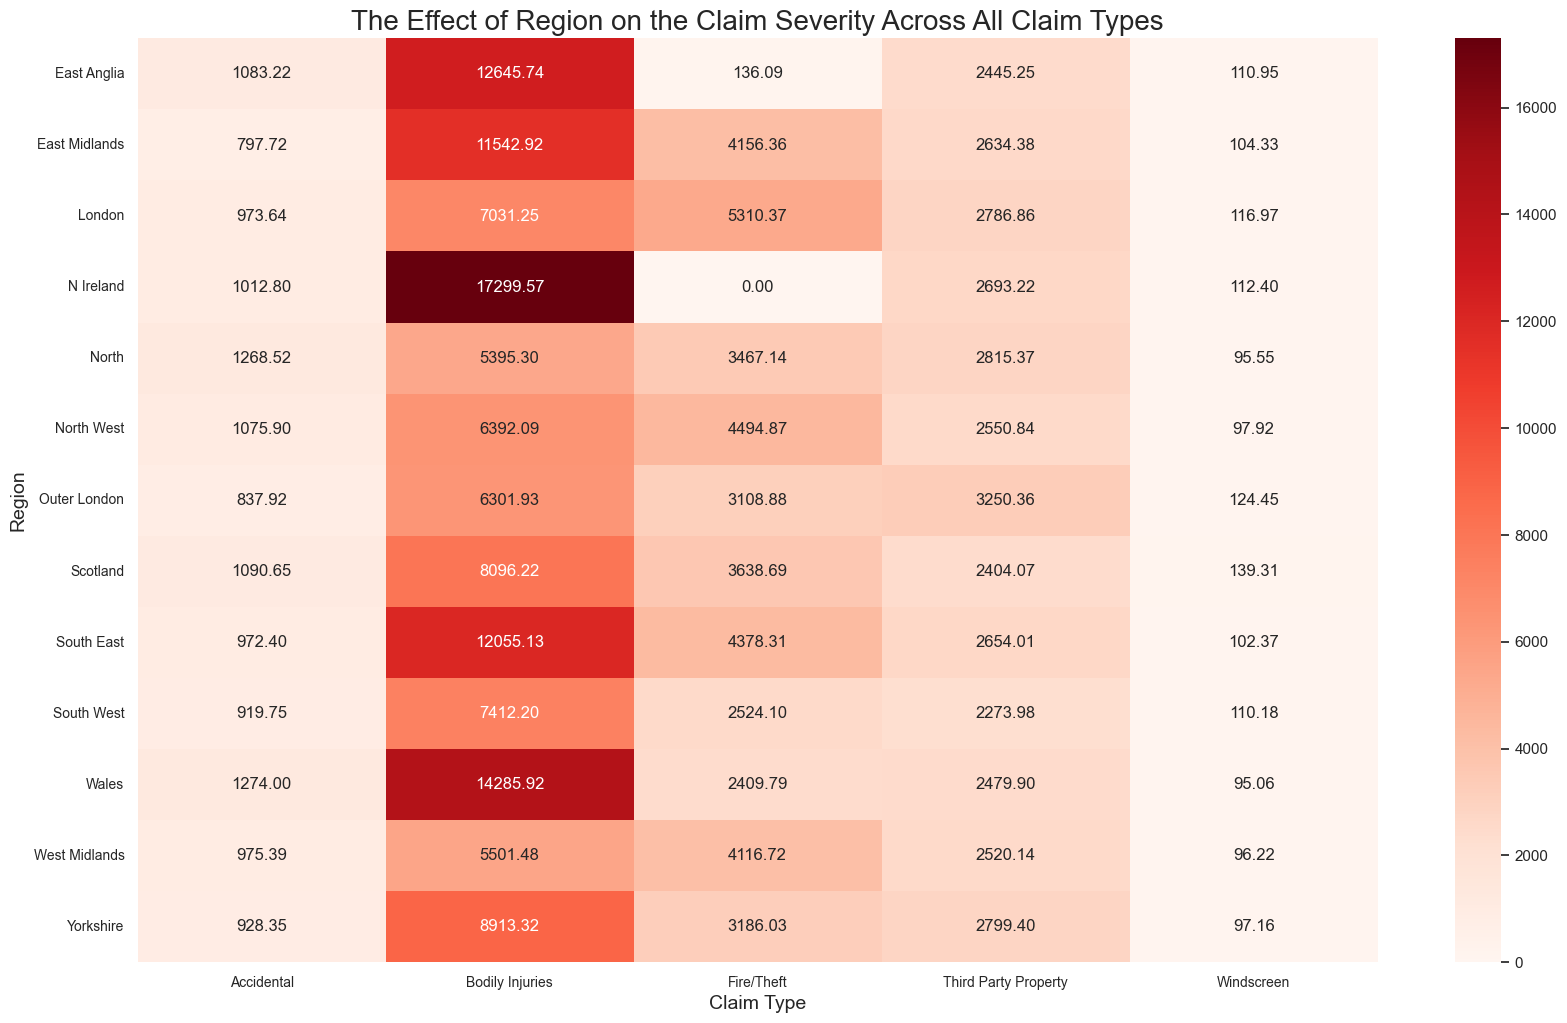

In [37]:
#Calculating Severity for each Region, for each claim type
severity_by_region_type, s_pivot5 = severity_calc(df = df_claimed,
                                              by_group = "region")

s_pivot5 = s_pivot5.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot5,
            annot=True,
            fmt=".2f",
            cmap="Reds")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Region", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Region on the Claim Severity Across All Claim Types", fontsize = 20)

plt.show()

## Total Costs Incurred for Each Claim Type

In [38]:
# Aggregating by Claim Type and calculating the costs incurred for each

by_claim_type = (
    df_claimed.loc[:, ["bi_incurred", "ad_incurred", "pd_incurred", "th_incurred", "ws_incurred"]]
        .sum()
        .reset_index()
        .rename(columns={"index":"Type", 0:"total_incurred"})
    
)
by_claim_type["proportion"] = round((by_claim_type["total_incurred"] / by_claim_type["total_incurred"].sum()), 2)

by_claim_type = by_claim_type.sort_values("total_incurred", ascending = False)

by_claim_type["Type"] = by_claim_type["Type"].str.replace(
    {
        "ad_incurred":"Accidental",
        "pd_incurred":"Third Party Property",
        "ws_incurred":"Windscreen",
        "bi_incurred":"Bodily Injuries",
        "th_incurred": "Fire/Theft"
    }
)

by_claim_type = (
    by_claim_type.set_index('Type')
       .reindex(claims_by_type['Type'])
       .reset_index()
)

by_claim_type

,Type,total_incurred,proportion
0,Accidental,4969271.36,0.23
1,Third Party Property,8023300.89,0.38
2,Windscreen,200168.46,0.01
3,Bodily Injuries,7339314.17,0.35
4,Fire/Theft,619012.96,0.03


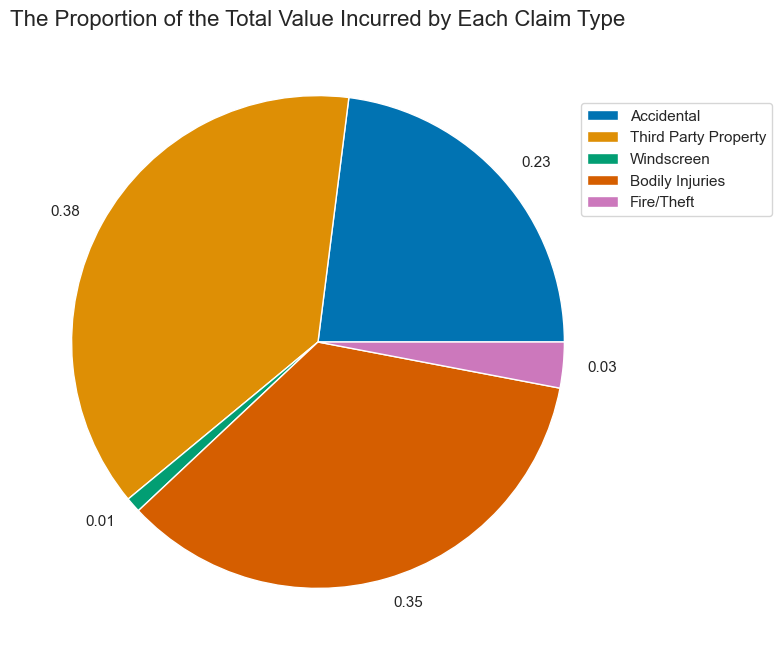

In [39]:
fig = plt.figure(figsize = (8, 8))

plt.pie(data = by_claim_type,
        x = "proportion",
        labels = round(by_claim_type["proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"], loc='upper right', bbox_to_anchor=(1.25, 0.9))
plt.title("The Proportion of the Total Value Incurred by Each Claim Type", fontsize = 16)

plt.show()

## Investigating Frequency by the Same Factors

### Frequency by Vehicle Use

In [40]:
#Calculating Frequency for each Vehicle-Use
frequency_by_use = (
    df.groupby("vehicle_use")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
frequency_by_use["frequency"] = round(frequency_by_use["claims"] / frequency_by_use["total_exposure"], 3)

frequency_by_use["vehicle_use"] = frequency_by_use["vehicle_use"].replace(
    {
        "B":"Business",
        "C":"Commuting and Social",
        "S":"Social/Domestic/Pleasure"
    }
)

frequency_by_use

#frequency_by_use.to_csv(Path.cwd() / "Reports" / "frequency_by_vehicle_use.csv", index = False)

,vehicle_use,total_exposure,claims,frequency
0,Business,150.838851,16,0.106
1,Commuting and Social,45955.546322,5354,0.117
2,Social/Domestic/Pleasure,25853.089141,2564,0.099


In [41]:
#Calculating Frequency for each Vehicle-Use, for each claim type
frequency_by_use_type, f_pivot = frequency_calc(df = df,
                                                   by_group = "vehicle_use",
                                                   key = {
        "B":"Business",
        "C":"Commuting and Social",
        "S":"Social/Domestic/Pleasure"
    })

f_pivot

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
vehicle_use,,,,,
Business,0.086185,0.00663,0.00663,0.033148,0.019889
Commuting and Social,0.072548,0.012273,0.002089,0.043499,0.029398
Social/Domestic/Pleasure,0.061733,0.011295,0.002592,0.041001,0.021274


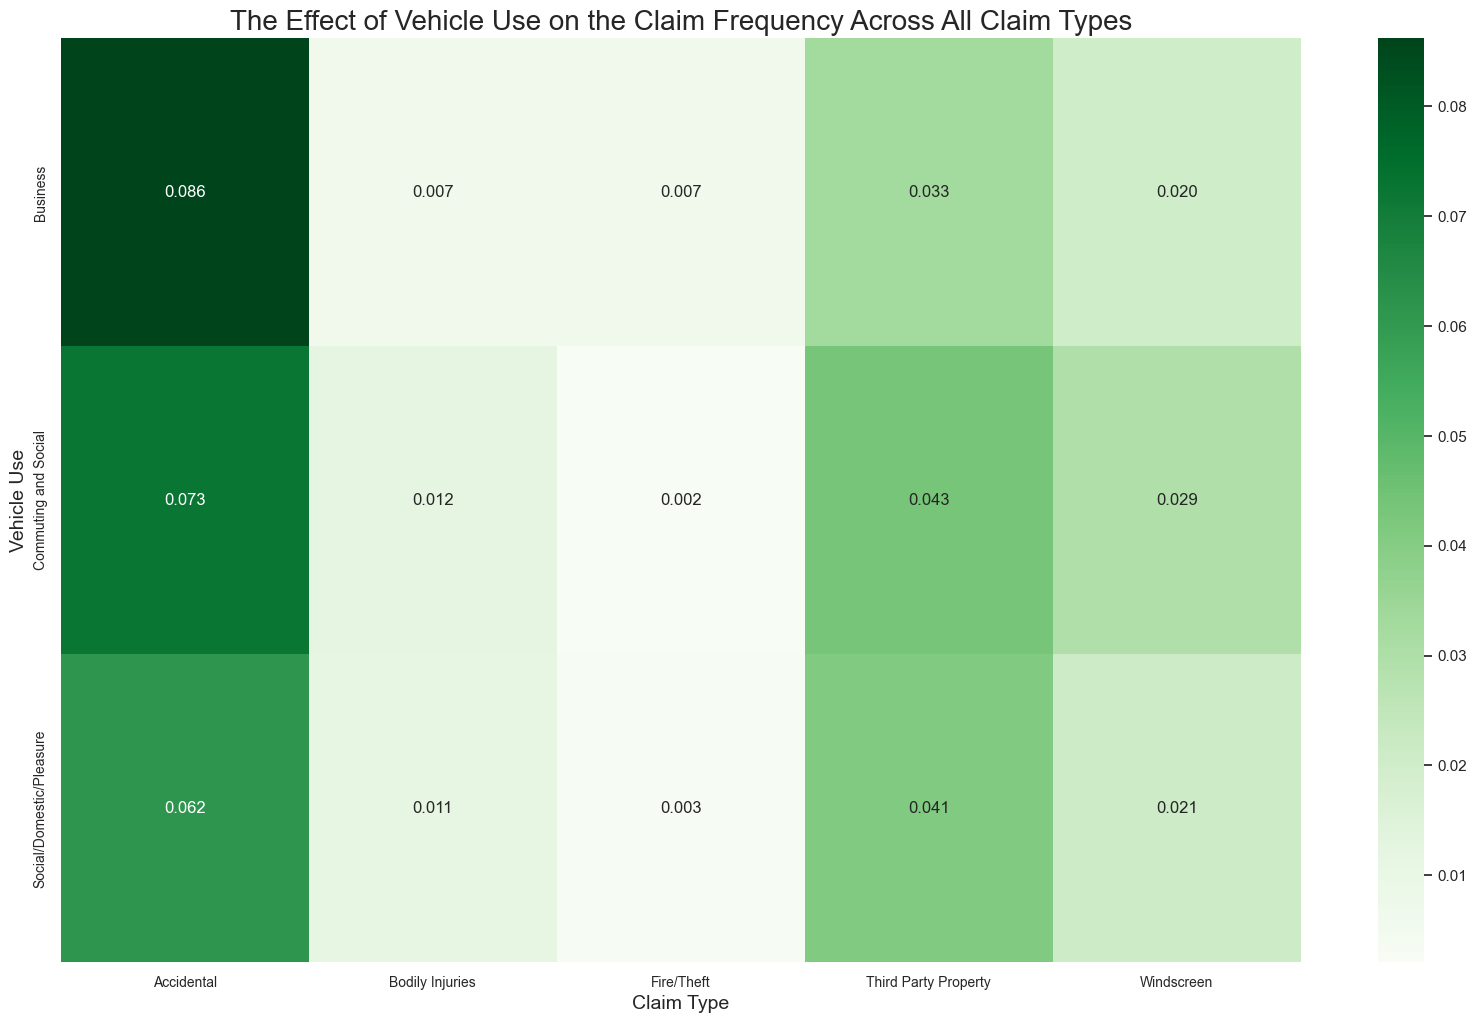

In [42]:
f_pivot = f_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Use", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Use on the Claim Frequency Across All Claim Types", fontsize = 20)

plt.show()

### Frequency by Overnight Location

In [43]:
#Calculating Frequency for each Overnight Location
frequency_by_loc = (
    df.groupby("overnight_location")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
frequency_by_loc["frequency"] = round(frequency_by_loc["claims"] / frequency_by_loc["total_exposure"], 3)

frequency_by_loc["overnight_location"] = frequency_by_loc["overnight_location"].replace(
    {
        "D":"Driveway",
        "G":"Garage",
        "R":"Road/Street"
    }
)

frequency_by_loc

#frequency_by_loc.to_csv(Path.cwd() / "Reports" / "frequency_by_loc.csv", index = False)

,overnight_location,total_exposure,claims,frequency
0,Driveway,47037.240261,5097,0.108
1,Garage,4489.268472,418,0.093
2,Road/Street,20432.965581,2419,0.118


In [44]:
#Calculating Frequency for each Overnight Location, for each claim type
frequency_by_loc_type, f_pivot2 = frequency_calc(df = df,
                                                   by_group = "overnight_location",
                                                   key = {
        "D":"Driveway",
        "G":"Garage",
        "R":"Road/Street"
    })

frequency_by_loc_type

,overnight_location,total_exposure,claims,frequency,claim_type
0,Driveway,47037.240261,3096,0.06582,Accidental
1,Garage,4489.268472,261,0.058139,Accidental
2,Road/Street,20432.965581,1586,0.07762,Accidental
3,Driveway,47037.240261,516,0.01097,Bodily Injuries
4,Garage,4489.268472,55,0.012251,Bodily Injuries
5,Road/Street,20432.965581,286,0.013997,Bodily Injuries
6,Driveway,47037.240261,1920,0.040819,Third Party Property
7,Garage,4489.268472,179,0.039873,Third Party Property
8,Road/Street,20432.965581,965,0.047228,Third Party Property
9,Driveway,47037.240261,101,0.002147,Fire/Theft


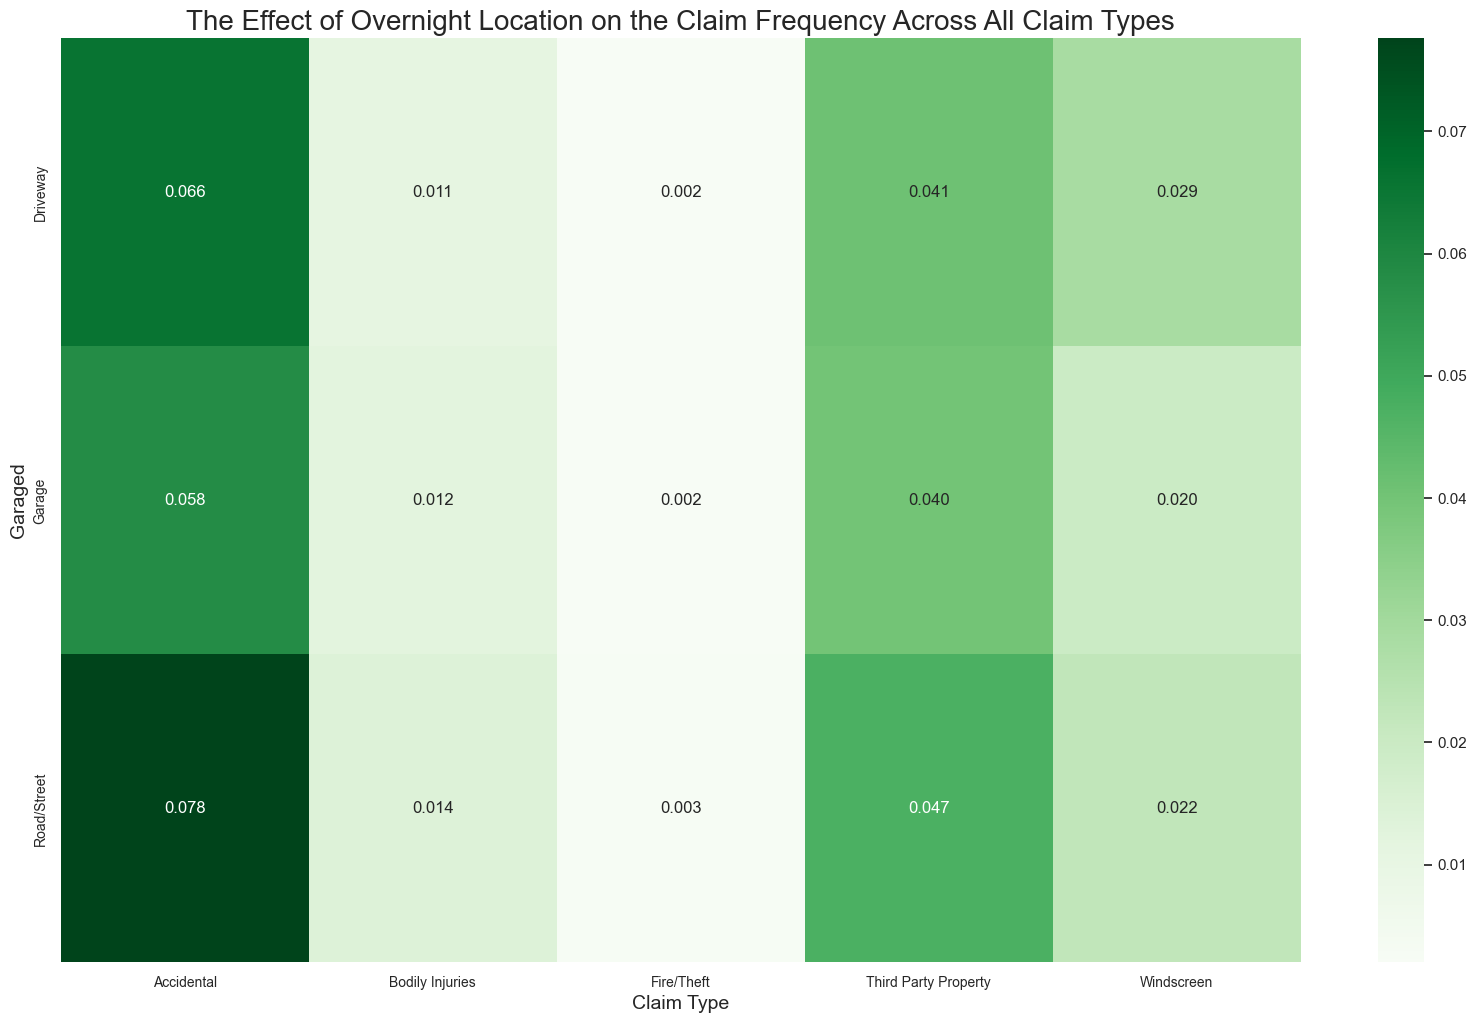

In [45]:
f_pivot2 = f_pivot2.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot2,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Garaged", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Overnight Location on the Claim Frequency Across All Claim Types", fontsize = 20)

plt.show()

### Frequency by Experience

In [46]:
#Calculating Frequency for each Experience band
frequency_by_exp = (
    df.groupby("experience_group")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
frequency_by_exp["frequency"] = round(frequency_by_exp["claims"] / frequency_by_exp["total_exposure"], 3)

frequency_by_exp

#frequency_by_exp.to_csv(Path.cwd() / "Reports" / "frequency_by_experience.csv", index = False)

,experience_group,total_exposure,claims,frequency
0,<0 years,365.120436,47,0.129
1,0-10 years,24883.557831,3320,0.133
2,10-20 years,16001.789919,1833,0.115
3,20-30 years,22682.314090,2097,0.092
4,30-40 years,4802.988709,399,0.083
5,40-50 years,2946.164704,218,0.074
6,50-60 years,227.600861,15,0.066
7,60+ years,47.429224,5,0.105


In [47]:
#Calculating Frequency for each Experience band, for each claim type
frequency_by_exp_type, f_pivot3 = frequency_calc(df = df,
                                                 by_group = "experience_group")

f_pivot3

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
experience_group,,,,,
<0 years,0.084903,0.024649,0.0,0.068471,0.021911
0-10 years,0.084715,0.017843,0.002371,0.058995,0.027448
10-20 years,0.070492,0.011686,0.002812,0.041245,0.028872
20-30 years,0.057181,0.007539,0.001896,0.029979,0.025571
30-40 years,0.048095,0.006454,0.002498,0.027691,0.023735
40-50 years,0.045483,0.004752,0.001697,0.02953,0.019008
50-60 years,0.057118,0.004394,0.0,0.030756,0.004394
60+ years,0.021084,0.0,0.0,0.084336,0.0


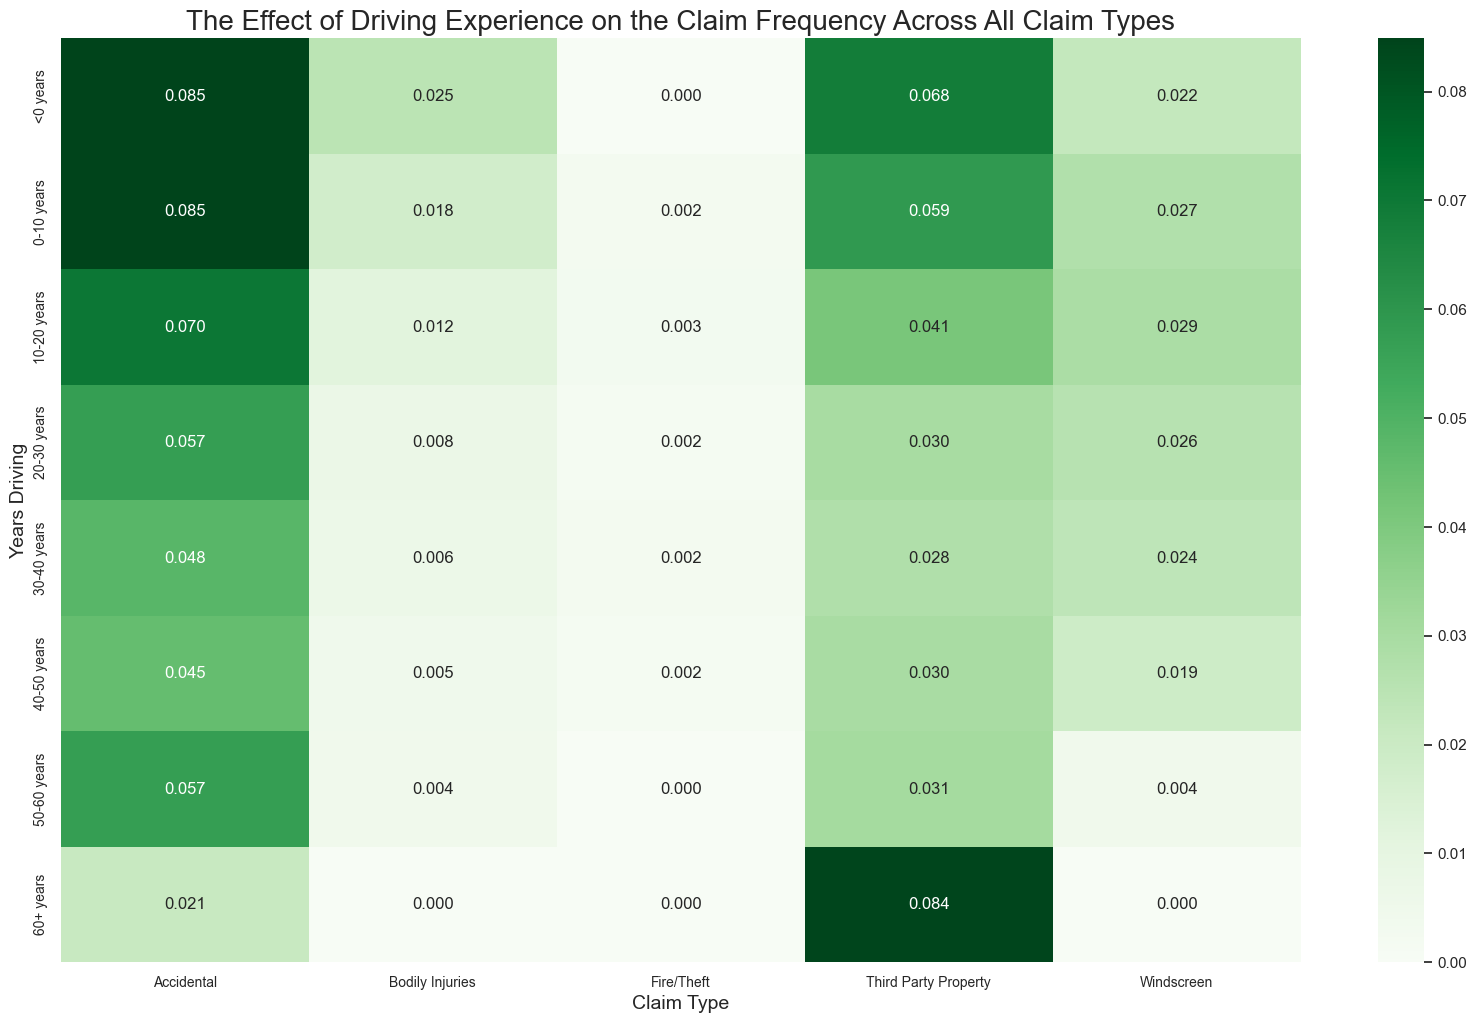

In [48]:
f_pivot3 = f_pivot3.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot3,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Years Driving", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Driving Experience on the Claim Frequency Across All Claim Types", fontsize = 20)

plt.show()

### Frequency by Vehicle Value

In [49]:
#Calculating Frequency for each Vehicle Value band
frequency_by_value = (
    df.groupby("vehicle_value_band")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
frequency_by_value["frequency"] = round(frequency_by_value["claims"] / frequency_by_value["total_exposure"], 3)

frequency_by_value

#frequency_by_value.to_csv(Path.cwd() / "Reports" / "frequency_by_value.csv", index = False)

,vehicle_value_band,total_exposure,claims,frequency
0,£0-2000,21538.505500,2221,0.103
1,£2000-4000,15967.808974,1699,0.106
2,£4000-6000,11308.452514,1279,0.113
3,£6000-8000,7395.963764,843,0.114
4,£8000-10000,4635.103554,557,0.120
5,£10000+,11113.640008,1335,0.120


In [50]:
#Calculating Frequency for each Vehicle Value band, for each claim type
frequency_by_value_type, f_pivot4 = frequency_calc(df = df,
                                                 by_group = "vehicle_value_band")

f_pivot4

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
vehicle_value_band,,,,,
£0-2000,0.059614,0.013743,0.001718,0.048657,0.021589
£2000-4000,0.066634,0.012212,0.001941,0.041521,0.02599
£4000-6000,0.074192,0.011142,0.001945,0.042358,0.025733
£6000-8000,0.075987,0.00987,0.001893,0.036236,0.02934
£8000-10000,0.071627,0.012297,0.003452,0.042933,0.034519
£10000+,0.077562,0.009898,0.003959,0.036622,0.032033


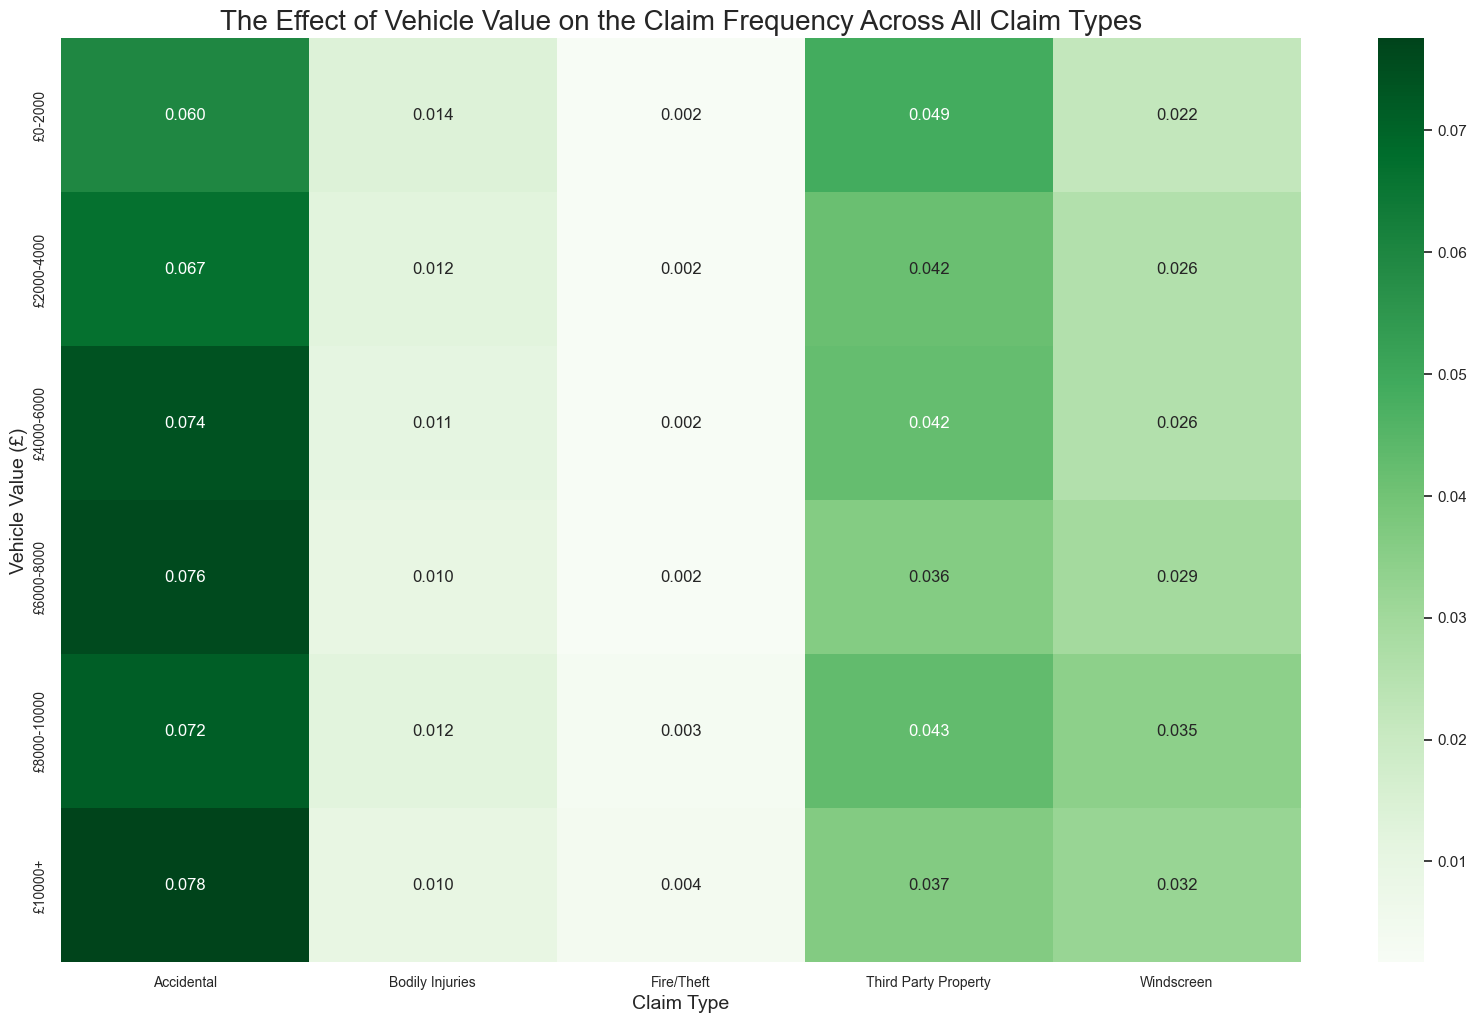

In [51]:
f_pivot4 = f_pivot4.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot4,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Value (£)", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Value on the Claim Frequency Across All Claim Types", fontsize = 20)

plt.show()

### Frequency by Region

In [52]:
#Calculating Frequency for Region
frequency_by_region = (
    df.groupby("region")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
    .reset_index()
)
frequency_by_region["frequency"] = round(frequency_by_region["claims"] / frequency_by_region["total_exposure"], 3)

frequency_by_region = frequency_by_region.sort_values("frequency", ascending = False)

frequency_by_region

#frequency_by_region.to_csv(Path.cwd() / "Reports" / "frequency_by_region.csv", index = False)

,region,total_exposure,claims,frequency
2,London,1965.129621,263,0.134
0,East Anglia,3458.052480,453,0.131
6,Outer London,3503.315498,445,0.127
8,South East,11184.643265,1378,0.123
1,East Midlands,4429.456118,526,0.119
9,South West,7854.695738,902,0.115
11,West Midlands,5748.343163,629,0.109
5,North West,9924.150652,1033,0.104
12,Yorkshire,8271.101676,860,0.104
10,Wales,4614.313907,458,0.099


In [53]:
#Calculating Frequency for each Region, for each claim type
frequency_by_region_type, f_pivot5 = frequency_calc(df = df,
                                                 by_group = "region")

f_pivot5

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
region,,,,,
East Anglia,0.068536,0.007808,0.001446,0.03875,0.052342
East Midlands,0.073372,0.011288,0.003161,0.040186,0.03409
London,0.080911,0.016793,0.004071,0.055467,0.025952
N Ireland,0.044281,0.005693,0.0,0.024038,0.022773
North,0.062591,0.013731,0.00107,0.039053,0.017476
North West,0.064388,0.016626,0.003124,0.042825,0.019246
Outer London,0.084777,0.01256,0.003711,0.047669,0.024548
Scotland,0.065044,0.01057,0.002168,0.041195,0.018971
South East,0.072063,0.010193,0.001967,0.046582,0.034869


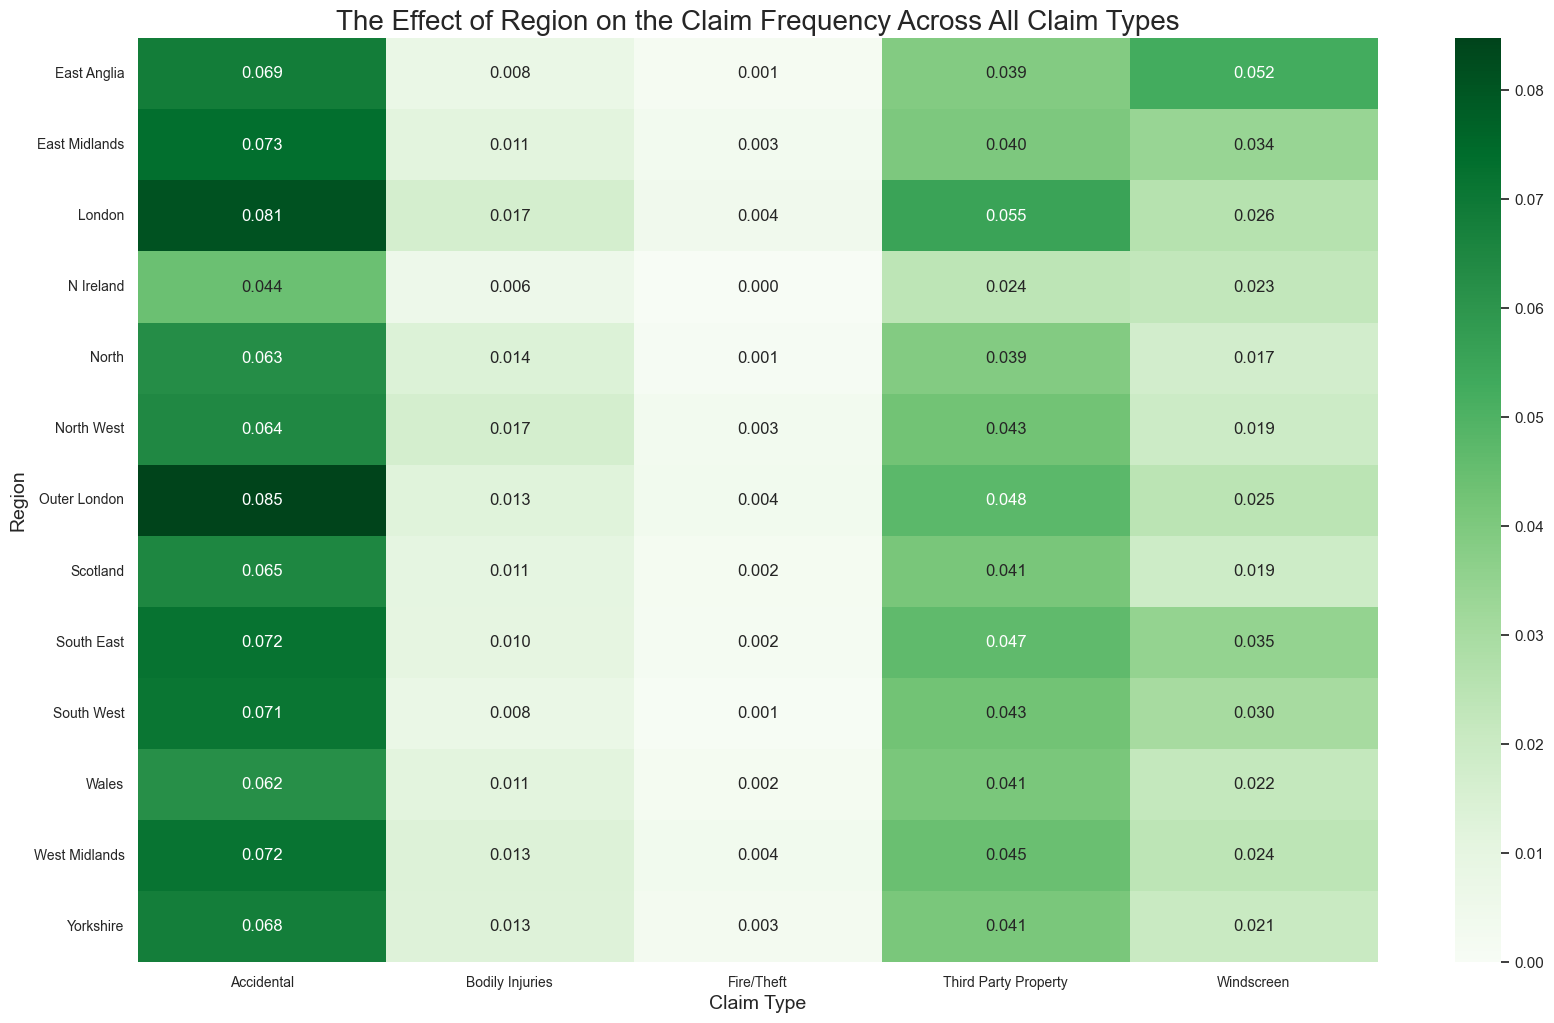

In [54]:
f_pivot5 = f_pivot5.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot5,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Region", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Region on the Claim Frequency Across All Claim Types", fontsize = 20)

plt.show()

## Miscellaneous Pricing Opportunities

### Identifying Customers to Promote PNCD

In [55]:
offer_pncd = (
    df[(df["claim_count"] == 0) & (df["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

offer_pncd.head()

,id,ncd,pncd,claim_count
0,16042,0,N,0
1,65415,0,N,0
2,89268,8,N,0
3,47359,9,N,0
4,22527,0,N,0


In [56]:
df[df["pncd"] == "Y"].final_incurred.mean()

np.float64(170.4059023294408)

In [57]:
df[df["pncd"] == "N"].final_incurred.mean()

np.float64(221.13835240862636)

### Identifying Customers to Change NCD

In [58]:
#Extracing customers who need their NCD reduced
ncd_to_reduce = (
    df_claimed[(df_claimed["ncd"] > 0) & (df_claimed["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

ncd_to_reduce.head()

,id,ncd,pncd,claim_count
0,61956,6,N,1
1,35145,3,N,1
2,93633,9,N,1
3,54363,1,N,1
4,59231,2,N,1


In [59]:
#Identifying the number of customers who need NCD increased/decreased
ncd_change = df.loc[:, ["id", "ncd", "pncd", "claim_count"]]

ncd_change["ncd_change"] = np.select(
    [(ncd_change["claim_count"] > 0) & (ncd_change["pncd"] == "Y"),
     (ncd_change["claim_count"] > 0) & (ncd_change["pncd"] == "N")],
    ["protected",
    "decrease"],
     "increase"
)

ncd_change = (
    ncd_change.groupby("ncd_change").id.count()
    .reset_index()
    .rename(columns = {"ncd_change":"NCD Change",
                      "id":"Number of Customers"})
)

ncd_change

#ncd_change.to_csv(Path.cwd() / "Reports" / "ncd_change.csv", index = False)

,NCD Change,Number of Customers
0,decrease,3797
1,increase,92581
2,protected,3622


In [60]:
#Identifying customers we could offer pNCD to
offer_pncd = df[(df["pncd"] == "N") & (df["claim_count"] == 0)].loc[:, ["id", "pncd", "ncd", "claim_count"]]

offer_pncd.shape

offer_pncd_summary = pd.DataFrame(
    {
        "Number of Customers":offer_pncd.shape[0],
        "Minimum NCD":offer_pncd["ncd"].min(),
        "Median NCD":offer_pncd["ncd"].median(),
        "Maximum NCD":offer_pncd["ncd"].max()
    },
    index = [0]
)

offer_pncd_summary

#offer_pncd_summary.to_csv(Path.cwd() / "Reports" / "offer_pncd_summary.csv", index = False)

,Number of Customers,Minimum NCD,Median NCD,Maximum NCD
0,46792,0,2.0,9


In [61]:
### Identifying Business Providers to Promote On

In [62]:
by_provider = df.groupby("business_group").id.count().reset_index()

by_provider = (
    by_provider
        .rename(columns = {"business_group":"Channel", "id":"Policies"})
        .sort_values("Policies", ascending = False,)
        .reset_index(drop = True)
)

by_provider

#by_provider.to_csv(Path.cwd() / "Reports" / "policies_by_channel.csv", index = False)

,Channel,Policies
0,Price Comparison Website,94521
1,Hastings Website,3472
2,Cashback/Rewards,863
3,Google,568
4,Unknown,388
5,Bing,89
6,Existing Customer,59
7,Direct Marketing,17
8,Email,15
9,Programmatic Advertising,7


<Figure size 1600x900 with 0 Axes>

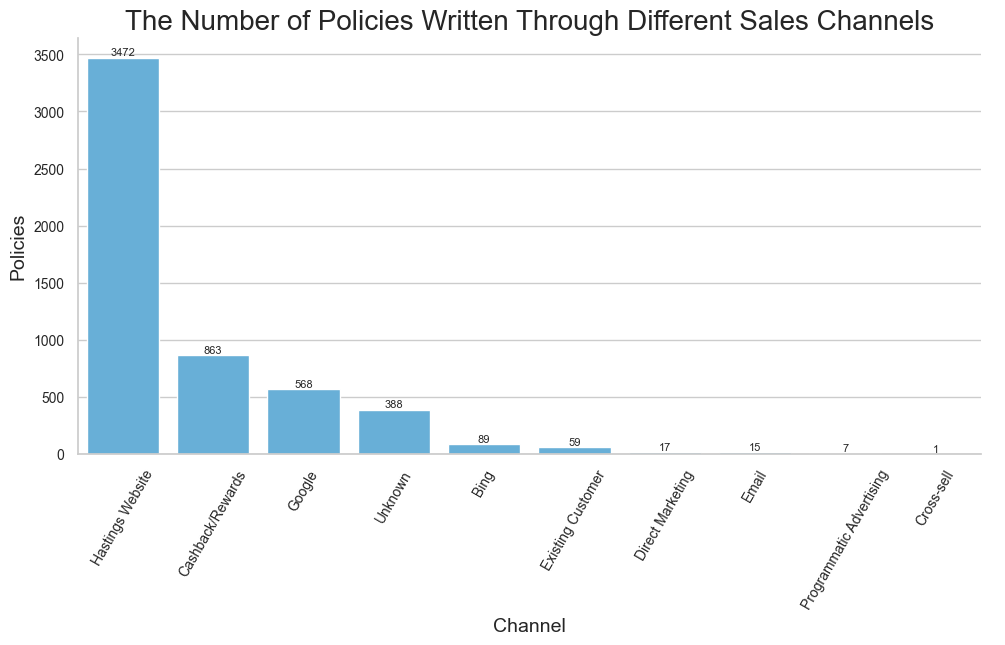

In [63]:
#Subset without Price Comparison
by_provider_subset = by_provider[by_provider["Channel"] != "Price Comparison Website"]

sns.set_theme(style = "whitegrid")

fig = plt.figure(figsize = (16,9))

sns.catplot(data = by_provider_subset,
            x = "Channel",
            y = "Policies",
           kind = "bar",
           aspect=2,
           color = sns.color_palette("colorblind")[9])

plt.xlabel("Channel", fontsize = 14)
plt.xticks(fontsize = 10, rotation = 60)
plt.ylabel("Policies", fontsize = 14)
plt.yticks(fontsize = 10)
plt.title("The Number of Policies Written Through Different Sales Channels", fontsize = 20)

for i, v in enumerate(by_provider_subset["Policies"]):
    plt.text(i, v, str(v), fontsize = 8, ha = "center", va = "bottom")

plt.show()

## Pure Premium of Each Combination

### Vehicle Use

In [66]:
#Using Frequency and Severity data to calculate pure premium

final_vehicle_use = (
    severity_by_use_type
        .drop(columns=["total_incurred", "claims"])
    .merge(frequency_by_use_type.loc[:, ["vehicle_use", "claim_type", "frequency"]], on = ["vehicle_use", "claim_type"])
)

final_vehicle_use["pp"] = final_vehicle_use["severity"] * final_vehicle_use["frequency"]

final_vehicle_use_pivot = final_vehicle_use.pivot(
        index="vehicle_use",
        columns="claim_type",
        values="pp"
    )

final_vehicle_use

,vehicle_use,severity,claim_type,frequency,pp
0,Business,765.345385,Accidental,0.086185,65.961057
1,Commuting and Social,1031.578809,Accidental,0.072548,74.839362
2,Social/Domestic/Pleasure,952.404837,Accidental,0.061733,58.795222
3,Business,15616.3,Bodily Injuries,0.00663,103.529693
4,Commuting and Social,8367.874113,Bodily Injuries,0.012273,102.696657
5,Social/Domestic/Pleasure,8918.550925,Bodily Injuries,0.011295,100.731362
6,Business,1242.126,Third Party Property,0.033148,41.173941
7,Commuting and Social,2679.348819,Third Party Property,0.043499,116.54781
8,Social/Domestic/Pleasure,2510.445255,Third Party Property,0.041001,102.930522
9,Business,12.0,Fire/Theft,0.00663,0.079555


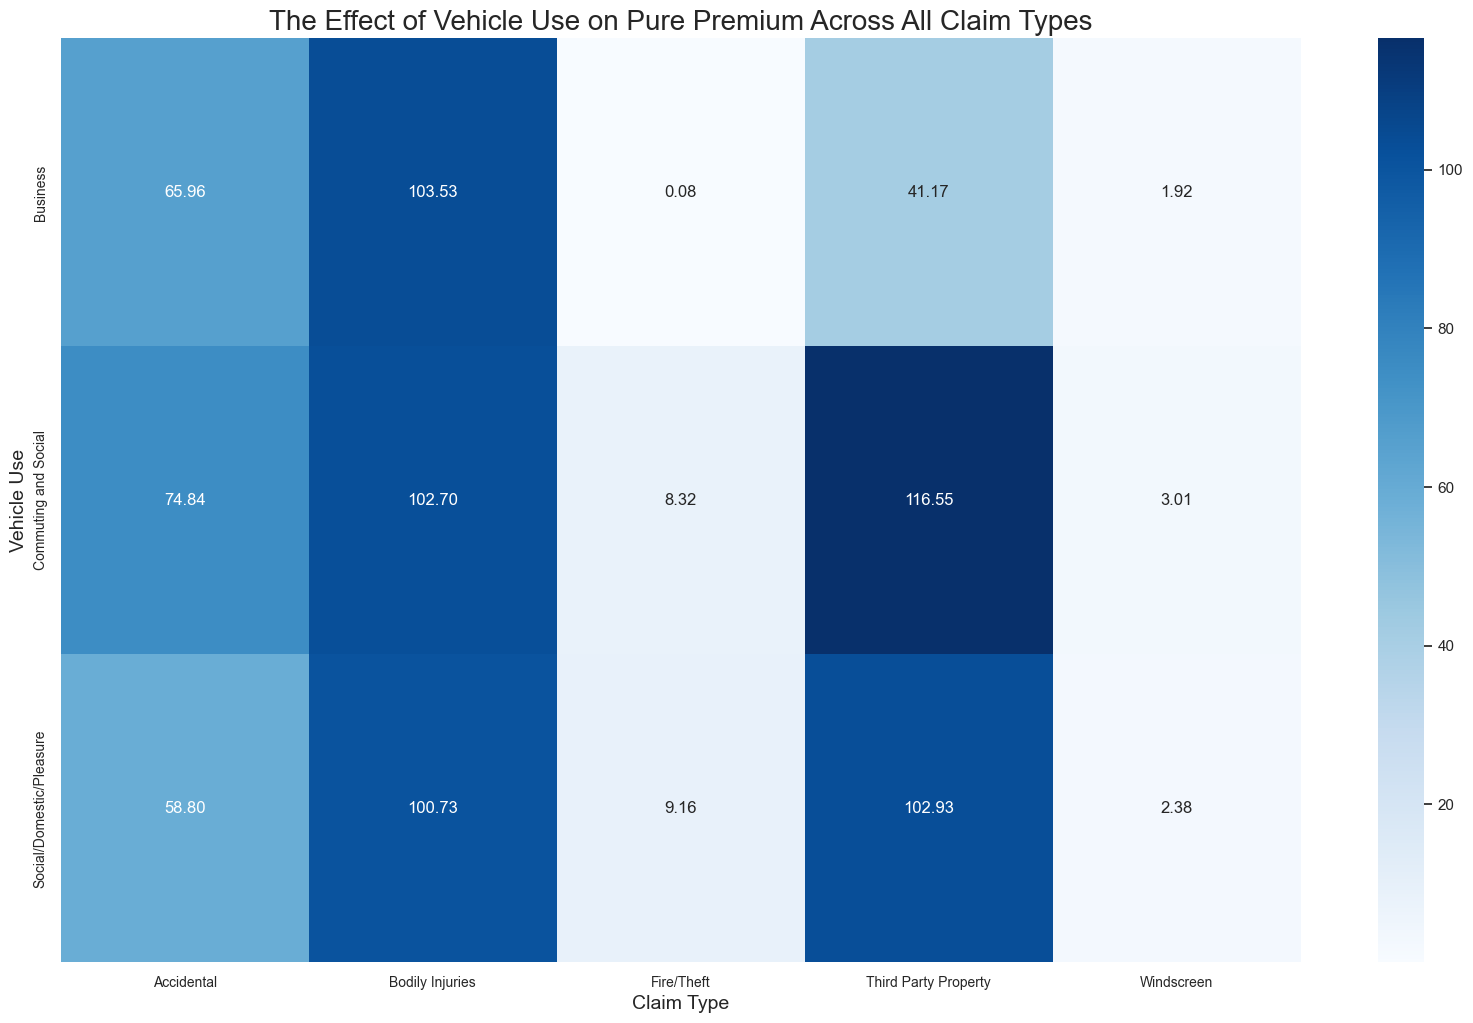

In [80]:
final_vehicle_use_pivot = final_vehicle_use_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = final_vehicle_use_pivot,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Use", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Use on Pure Premium Across All Claim Types", fontsize = 20)

plt.show()

### Overnight Location

In [72]:
#Using Frequency and Severity data to calculate pure premium

final_loc = (
    severity_by_loc_type
        .drop(columns=["total_incurred", "claims"])
    .merge(frequency_by_loc_type.loc[:, ["overnight_location", "claim_type", "frequency"]], on = ["overnight_location", "claim_type"])
)

final_loc["pp"] = final_loc["severity"] * final_loc["frequency"]

final_loc_pivot = final_loc.pivot(
        index="overnight_location",
        columns="claim_type",
        values="pp"
    )

final_loc_pivot

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
overnight_location,,,,,
Driveway,68.615665,74.37573,9.449062,106.035548,3.085562
Garage,71.005034,92.61165,11.7646,104.397336,2.575132
Road/Street,69.643301,167.627481,5.958053,125.630988,2.127528


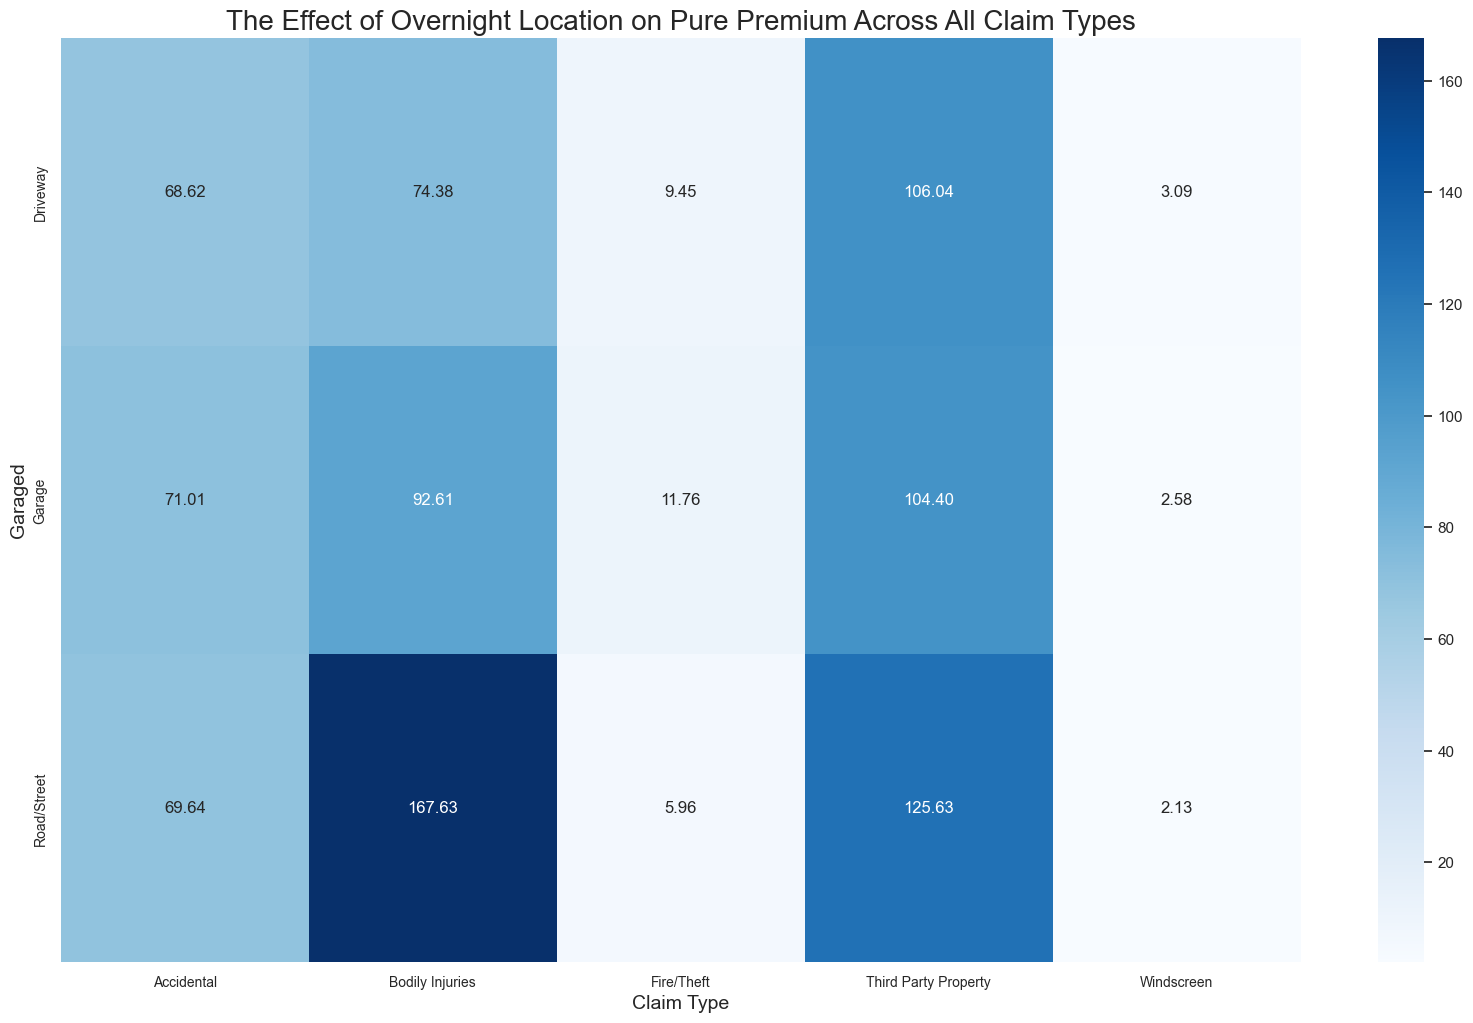

In [73]:
final_loc_pivot = final_loc_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = final_loc_pivot,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Garaged", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Overnight Location on Pure Premium Across All Claim Types", fontsize = 20)

plt.show()

### Experience

In [74]:
#Using Frequency and Severity data to calculate pure premium

final_exp = (
    severity_by_exp_type
        .drop(columns=["total_incurred", "claims"])
    .merge(frequency_by_exp_type.loc[:, ["experience_group", "claim_type", "frequency"]], on = ["experience_group", "claim_type"])
)

final_exp["pp"] = final_exp["severity"] * final_exp["frequency"]

final_exp_pivot = final_exp.pivot(
        index="experience_group",
        columns="claim_type",
        values="pp"
    )

final_exp_pivot

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
experience_group,,,,,
<0 years,97.876143,144.676399,0.0,199.614738,1.740768
0-10 years,88.181283,172.570316,5.913244,169.589543,2.55218
10-20 years,65.006935,82.763,11.548148,97.033923,3.139945
20-30 years,57.572231,58.60037,11.416715,72.172068,2.770447
30-40 years,49.922932,46.113819,5.342303,67.745908,2.735349
40-50 years,47.260606,38.517242,0.835944,66.262171,3.156972
50-60 years,61.314179,16.766193,0.0,67.404666,2.205
60+ years,4.216809,0.0,0.0,99.87218,0.0


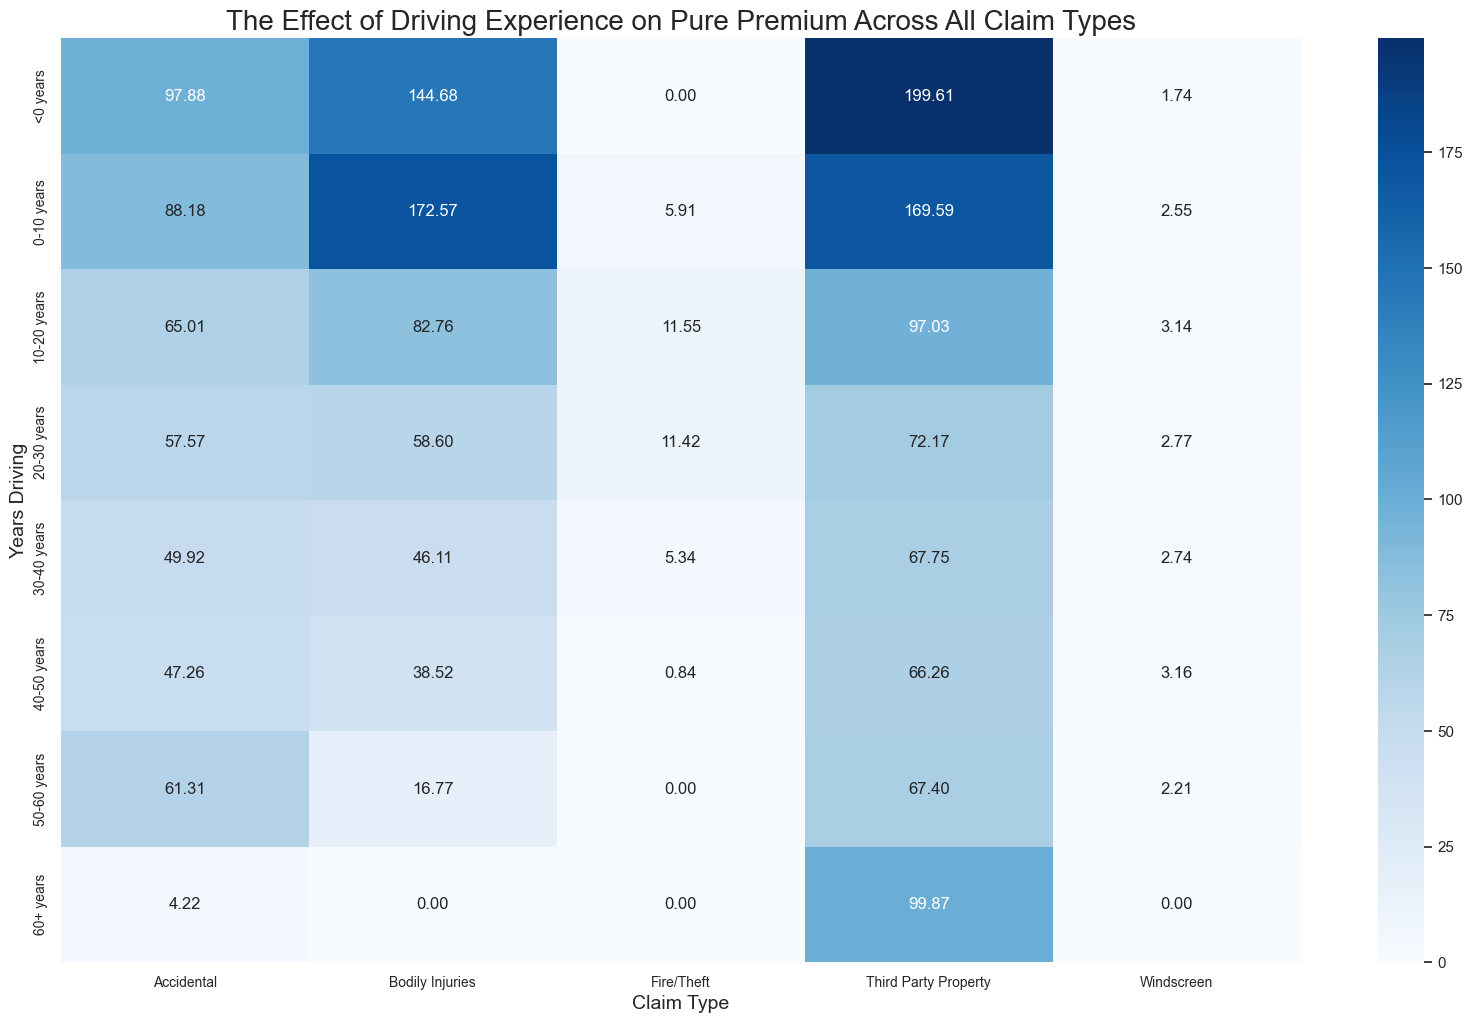

In [75]:
final_exp_pivot = final_exp_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = final_exp_pivot,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Years Driving", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Driving Experience on Pure Premium Across All Claim Types", fontsize = 20)

plt.show()

In [76]:
#Using Frequency and Severity data to calculate pure premium

final_value = (
    severity_by_value_type
        .drop(columns=["total_incurred", "claims"])
    .merge(frequency_by_value_type.loc[:, ["vehicle_value_band", "claim_type", "frequency"]], on = ["vehicle_value_band", "claim_type"])
)

final_value["pp"] = final_value["severity"] * final_value["frequency"]

final_value_pivot = final_value.pivot(
        index="vehicle_value_band",
        columns="claim_type",
        values="pp"
    )

final_value_pivot

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
vehicle_value_band,,,,,
£0-2000,30.398213,129.303405,0.953861,136.90812,1.914393
£2000-4000,51.436359,110.628579,3.6602,112.636675,2.331739
£4000-6000,78.364576,67.177618,5.799173,98.421594,2.225869
£6000-8000,97.147261,121.91087,5.051163,94.731136,2.499582
£8000-10000,100.990935,95.539706,16.857354,104.124239,3.497553
£10000+,127.809627,61.515071,32.298093,88.152315,5.563709


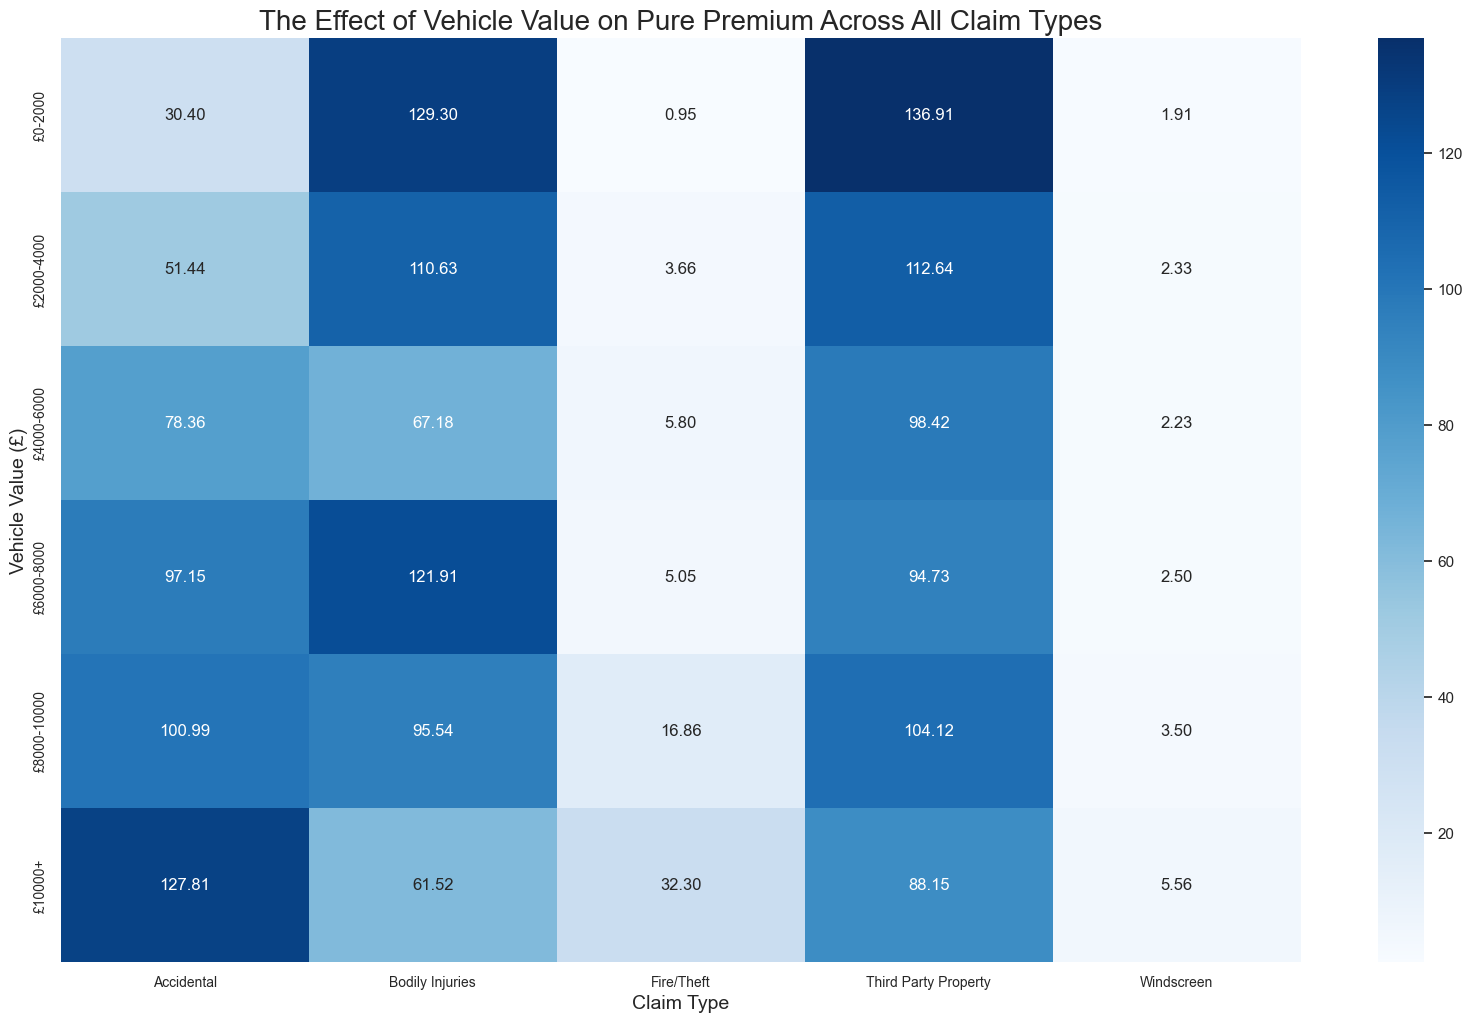

In [77]:
final_value_pivot = final_value_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = final_value_pivot,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Value (£)", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Value on Pure Premium Across All Claim Types", fontsize = 20)

plt.show()

In [78]:
#Using Frequency and Severity data to calculate pure premium

final_region = (
    severity_by_region_type
        .drop(columns=["total_incurred", "claims"])
    .merge(frequency_by_region_type.loc[:, ["region", "claim_type", "frequency"]], on = ["region", "claim_type"])
)

final_region["pp"] = final_region["severity"] * final_region["frequency"]

final_region_pivot = final_region.pivot(
        index="region",
        columns="claim_type",
        values="pp"
    )

final_region_pivot

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
region,,,,,
East Anglia,74.239134,98.736168,0.196773,94.753663,5.807558
East Midlands,58.530649,130.297207,13.136845,105.863814,3.556746
London,78.778116,118.074323,21.618391,154.578958,3.035774
N Ireland,44.848063,98.491897,0.0,64.740911,2.559625
North,79.398126,74.082057,3.709624,109.947658,1.669831
North West,69.275695,106.275613,14.040606,109.239343,1.884475
Outer London,71.036348,79.14932,11.536335,154.941777,3.055057
Scotland,70.94061,85.574523,7.88919,99.035123,2.642867
South East,70.074133,122.872491,8.612057,123.628543,3.569675


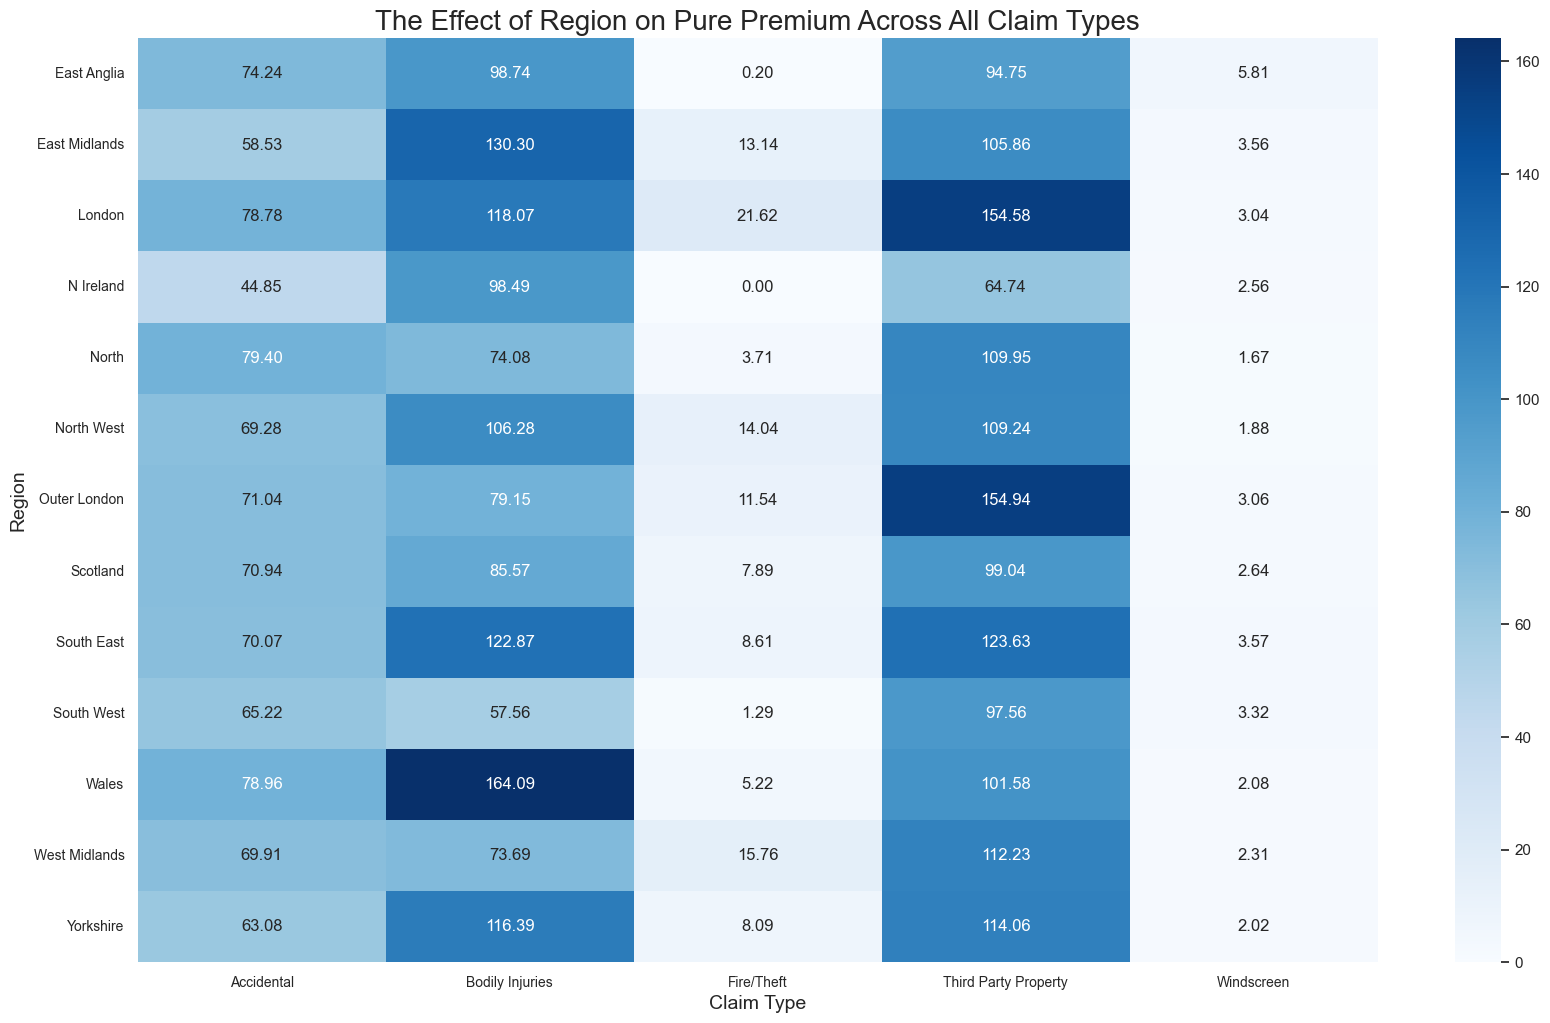

In [79]:
final_region_pivot = final_region_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = final_region_pivot,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Region", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Region on Pure Premium Across All Claim Types", fontsize = 20)

plt.show()